# Medical Transcriptions Data

### Phase 0 - Foundations & Framing
A clinical transcription is a formal record of a patient encounter, often dictated and transcribed. Unlike general text, it is dense with jargon, abbreviations, and shorthand.
- Challenges: Severe class imbalance (some specialties have 10x more data than others), high dimensionality, and overlapping vocabulary (e.g., "pain" appears in almost every specialty).

In [394]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("mtsamples.csv")
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


### Phase 1 - EDA & NLP Foundations

#### Data Cleaning & Engineering

In [395]:
# Load & Filter
n_before = len(df)
n_unique_trans = df["transcription"].nunique()
n_multi_specialty = (df.groupby("transcription")["medical_specialty"].nunique() > 1).sum() # this causes low performance for later model training

multi_specialty = df.groupby("transcription")["medical_specialty"].nunique() > 1
multi_specialty_df = df[df["transcription"].isin(multi_specialty.index)]

print("\nTranscriptions with Multiple Specialties:")
print("-"*100)
for text, group in list(multi_specialty_df.groupby("transcription"))[:10]:
    print(f"\nTranscription preview: {text[:100]}...")
    print(f"Assigned specialties:")
    for _, row in group.iterrows():
        print(f"  -> {row['medical_specialty']}")

df = df.dropna(subset=["transcription", "medical_specialty"]).reset_index(drop=True) # after cleaning, index was altered
df["transcription"] = df["transcription"].str.strip() # remove whitespace before and after transcription
df["medical_specialty"] = df["medical_specialty"].str.strip() # clean up specialty names
df = df.drop_duplicates(subset=["transcription"]).reset_index(drop=True)
df = df[df["transcription"].str.len() >= 20].reset_index(drop=True)


Transcriptions with Multiple Specialties:
----------------------------------------------------------------------------------------------------

Transcription preview: 1.  Odynophagia.,2.  Dysphagia.,3.  Gastroesophageal reflux disease rule out stricture.,POSTOPERATIV...
Assigned specialties:
  ->  Surgery
  ->  Gastroenterology

Transcription preview: 1.  Pelvic tumor.,2.  Cystocele.,3.  Rectocele.,POSTOPERATIVE DIAGNOSES:,1.  Degenerated joint.,2.  ...
Assigned specialties:
  ->  Urology
  ->  Surgery
  ->  Obstetrics / Gynecology

Transcription preview: 1.  The left ventricular cavity size and wall thickness appear normal.  The wall motion and left ven...
Assigned specialties:
  ->  Cardiovascular / Pulmonary
  ->  Radiology

Transcription preview: 2-D ECHOCARDIOGRAM,Multiple views of the heart and great vessels reveal normal intracardiac and grea...
Assigned specialties:
  ->  Cardiovascular / Pulmonary
  ->  Radiology

Transcription preview: 2-D M-MODE: , ,1.  Left atrial enlargem

In [396]:
print(f"Rows before cleaning: {n_before:,}")
print(f"Unique transcriptions: {n_unique_trans:,}")
print(f"Transcriptions with >1 specialty: {n_multi_specialty:,}")
print(f"Rows after cleaning: {len(df):,}")
df.head()

Rows before cleaning: 4,999
Unique transcriptions: 2,357
Transcriptions with >1 specialty: 2,148
Rows after cleaning: 2,351


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [397]:
# Feature Extraction
df["char_length"] = df["transcription"].str.len()
df["word_count"] = df["transcription"].str.split().str.len()
df["sentence_count"] = df["transcription"].str.count(r"[.!?]+")
print(df[["char_length", "word_count", "sentence_count"]].describe())

        char_length   word_count  sentence_count
count   2351.000000  2351.000000     2351.000000
mean    3013.061676   459.433858       44.217354
std     1983.817859   314.796855       29.038096
min       23.000000     3.000000        0.000000
25%     1576.000000   237.000000       23.000000
50%     2625.000000   390.000000       38.000000
75%     3950.500000   609.000000       59.000000
max    18425.000000  3029.000000      243.000000


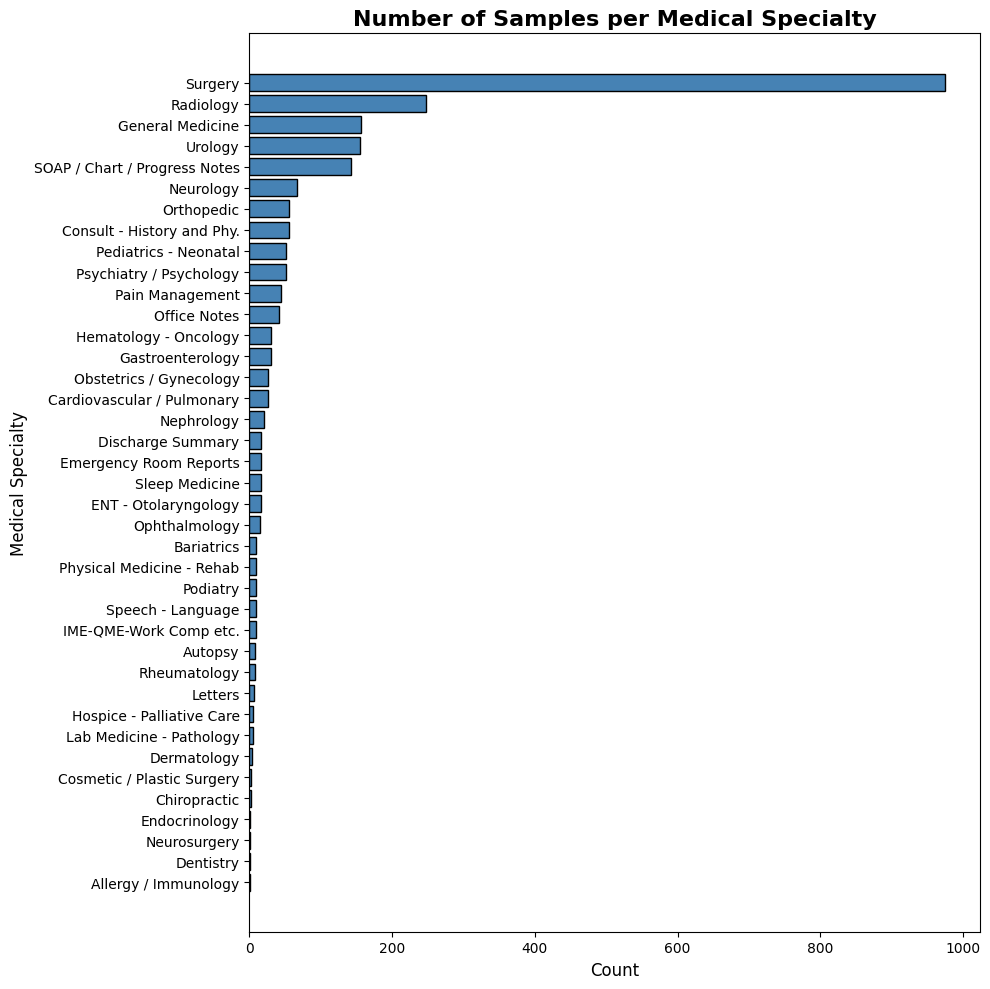

In [398]:
# Visualization
# Bar chart of samples per specialty
plt.figure(figsize=(10, 10))
specialty_counts = df["medical_specialty"].value_counts()
plt.barh(specialty_counts.index, specialty_counts.values, color="steelblue", edgecolor="black")
plt.title("Number of Samples per Medical Specialty", fontsize=16, fontweight="bold")
plt.xlabel("Count", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

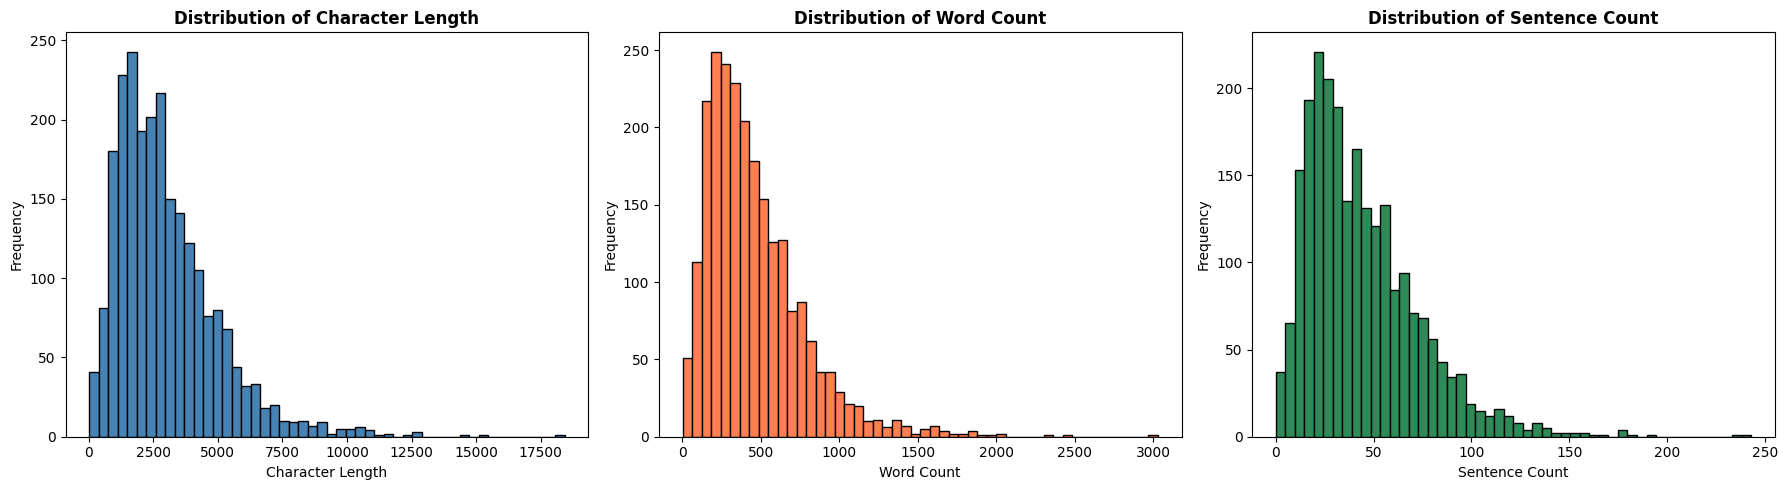

In [399]:
# Histogram of note lengths
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df["char_length"], bins=50, edgecolor="black", color="steelblue")
axes[0].set_title("Distribution of Character Length", fontweight="bold")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Frequency")
axes[1].hist(df["word_count"], bins=50, edgecolor="black", color="coral")
axes[1].set_title("Distribution of Word Count", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[2].hist(df["sentence_count"], bins=50, edgecolor="black", color="seagreen")
axes[2].set_title("Distribution of Sentence Count", fontweight="bold")
axes[2].set_xlabel("Sentence Count")
axes[2].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

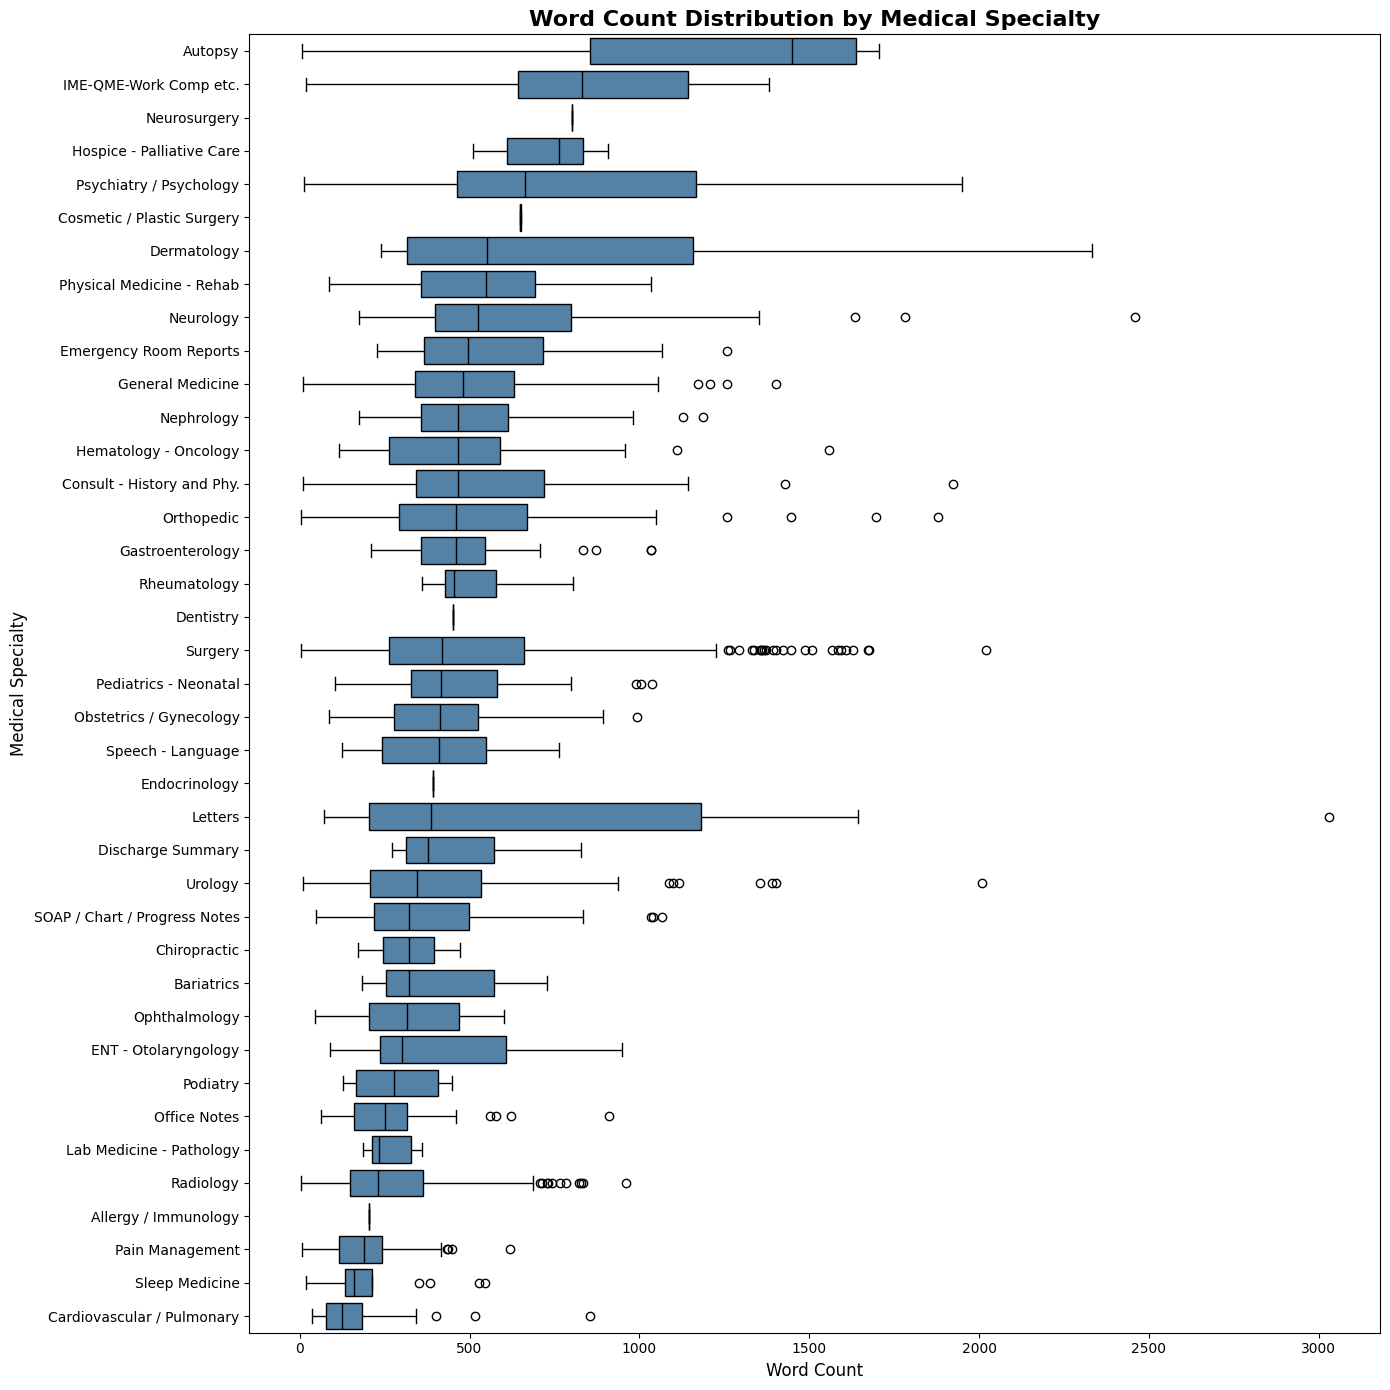

In [400]:
# Boxplots comparing note lengths across specialties
med_order = df.groupby("medical_specialty")["word_count"].median().sort_values().index
plt.figure(figsize=(14, 14))
sns.boxplot(data=df, x="word_count", y="medical_specialty", order=med_order, color="steelblue", linecolor="black")
plt.title("Word Count Distribution by Medical Specialty", fontsize=16, fontweight="bold")
plt.xlabel("Word Count", fontsize=12)
plt.ylabel("Medical Specialty", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### NLP Analysis

In [401]:
from collections import Counter
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk import ngrams
# Download required NLTK data (run once)
# nltk.download("stopwords")

In [402]:
# Preprocessing: lowercase text, remove punctuation, and filter out standard English stopwords
stop_words = set(stopwords.words("english"))
processed_words = []
for text in df["transcription"]:
    if not isinstance(text, str):
        processed_words.append([])
        continue
    text = text.lower()
    text = text.translate( # replace punctuation with space (not empty string)
        str.maketrans(string.punctuation, " " * len(string.punctuation))
    )
    text = re.sub(r"\s+", " ", text).strip() # normalize whitespace before splitting
    words = text.split() # split and filter
    words = [word for word in words if word not in stop_words and len(word) > 1]
    processed_words.append(words)
df["processed_words"] = processed_words

Top 20 Words Overall
--------------------------------------------------
patient        : 11,286
right          : 5,469
left           : 5,338
history        : 4,351
procedure      : 3,605
normal         : 3,430
placed         : 3,302
well           : 3,094
pain           : 2,683
also           : 2,029
time           : 1,992
mg             : 1,992
noted          : 1,988
using          : 1,923
blood          : 1,861
performed      : 1,854
skin           : 1,777
anesthesia     : 1,769
without        : 1,691
incision       : 1,678


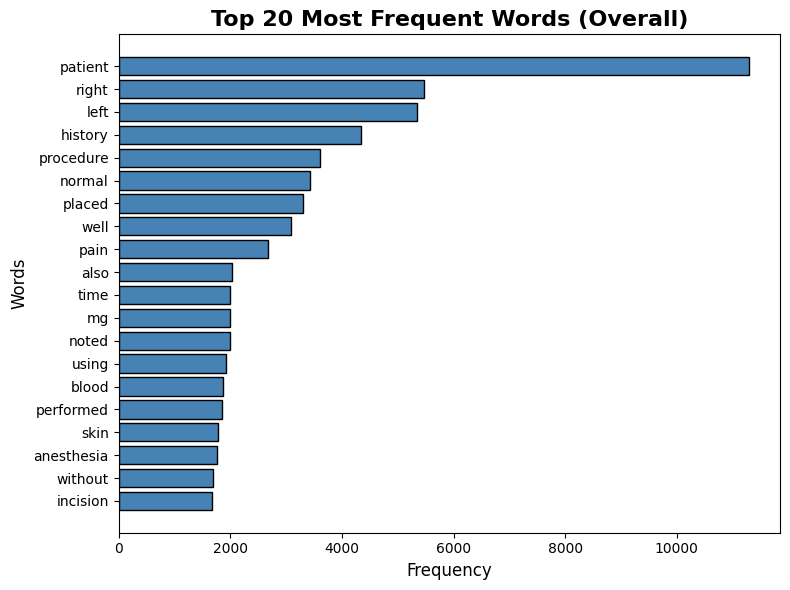

In [403]:
# Frequency Analysis
all_words = []
for words_list in df["processed_words"]:
    all_words.extend(words_list)

word_freq = Counter(all_words)
top_20_words = word_freq.most_common(20)
print("Top 20 Words Overall")
print("-"*50)
for word, count in top_20_words:
    print(f"{word:15s}: {count:,}")

plt.figure(figsize=(8, 6))
words, counts = zip(*top_20_words)
plt.barh(words, counts, color="steelblue", edgecolor="black")
plt.title("Top 20 Most Frequent Words (Overall)", fontsize=16, fontweight="bold")
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Words", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



Surgery
--------------------------------------------------
patient        : 4,774
left           : 3,036
right          : 2,996
procedure      : 2,930
placed         : 2,702
well           : 1,522
anesthesia     : 1,520
using          : 1,518
incision       : 1,485
removed        : 1,444
performed      : 1,368
used           : 1,338
skin           : 1,101
room           : 1,085
diagnosis      : 1,080
artery         : 1,070
taken          : 1,036
noted          : 1,033
fashion        : 1,002
anterior       : 996


Radiology
--------------------------------------------------
left           : 635
normal         : 604
right          : 582
exam           : 291
patient        : 284
mild           : 228
unremarkable   : 224
seen           : 201
findings       : 192
without        : 184
within         : 177
evidence       : 173
artery         : 172
impression     : 165
revealed       : 155
ct             : 154
images         : 139
10             : 134
mri            : 132
cm             : 12

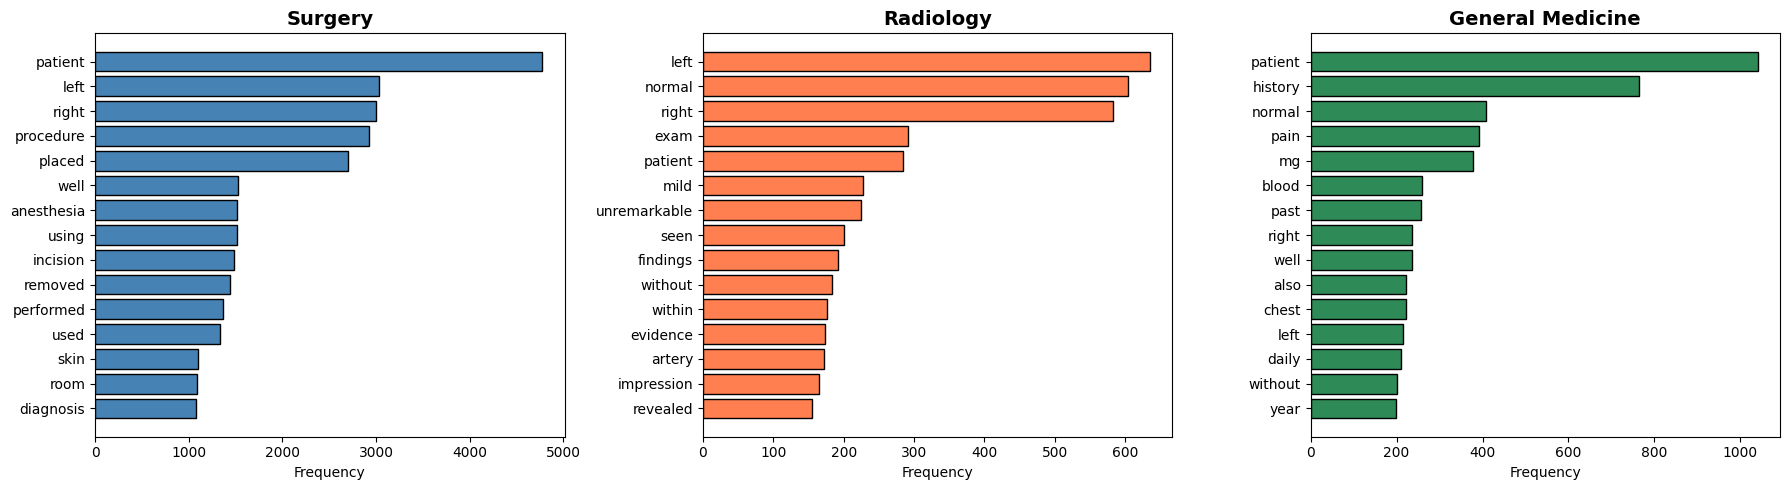

In [404]:
# Top 20 Words Per Specialty
specialties = df["medical_specialty"].value_counts().index

for specialty in specialties:
    print("\n")
    print(f"{specialty.strip()}")
    print(f"{'-'*50}")
    specialty_words = []
    for words_list in df[df["medical_specialty"] == specialty]["processed_words"]:
        specialty_words.extend(words_list)
    specialty_freq = Counter(specialty_words)
    top_specialty_words = specialty_freq.most_common(20)
    for word, count in top_specialty_words:
        print(f"{word:15s}: {count:,}")

colors = ["steelblue", "coral", "seagreen"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, specialty in enumerate(specialties[:3]):
    specialty_words = []
    for words_list in df[df["medical_specialty"] == specialty]["processed_words"]:
        specialty_words.extend(words_list)
    specialty_freq = Counter(specialty_words)
    top_words = specialty_freq.most_common(15)
    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=colors[idx], edgecolor="black")
    axes[idx].set_title(f"{specialty}", fontsize=14, fontweight="bold")
    axes[idx].set_xlabel("Frequency", fontsize=10)
    axes[idx].invert_yaxis()
plt.tight_layout()
plt.show()

Top 20 Bigrams (Overall)
--------------------------------------------------
year old                      : 1,381
operating room                : 743
prepped draped                : 717
blood pressure                : 606
preoperative diagnosis        : 568
procedure patient             : 558
medical history               : 557
tolerated procedure           : 546
procedure well                : 544
postoperative diagnosis       : 529
physical examination          : 524
incision made                 : 514
past medical                  : 507
coronary artery               : 506
vital signs                   : 503
patient tolerated             : 491
history present               : 485
present illness               : 480
mg daily                      : 473
blood loss                    : 454


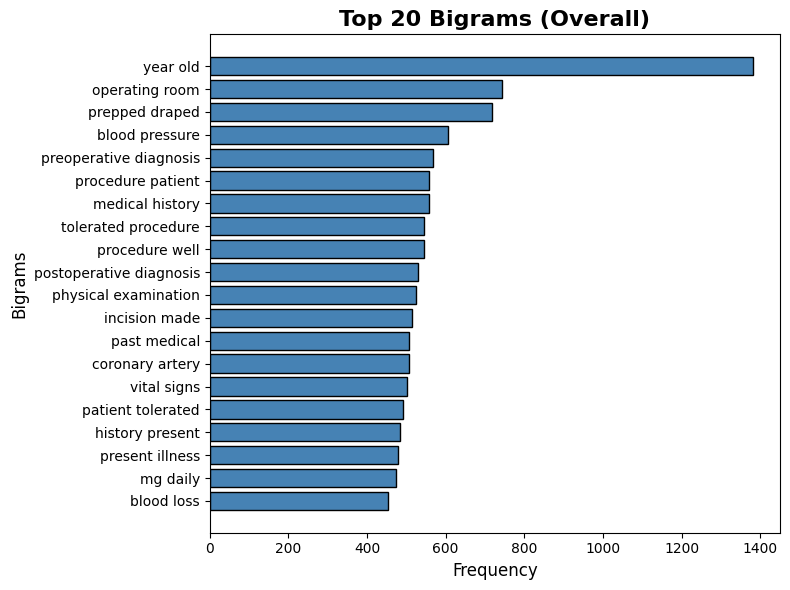

Top 10 Bigrams Per Specialty
--------------------------------------------------


Surgery
--------------------------------------------------
operating room                : 632
prepped draped                : 610
preoperative diagnosis        : 490
procedure patient             : 479
tolerated procedure           : 462
postoperative diagnosis       : 458
procedure well                : 456
incision made                 : 454
year old                      : 451
patient tolerated             : 411


Radiology
--------------------------------------------------
carotid artery                : 58
heart rate                    : 51
reason exam                   : 48
without contrast              : 46
coronary artery               : 43
exam unremarkable             : 42
central canal                 : 42
left ventricular              : 41
ejection fraction             : 38
internal carotid              : 36


General Medicine
--------------------------------------------------
year old        

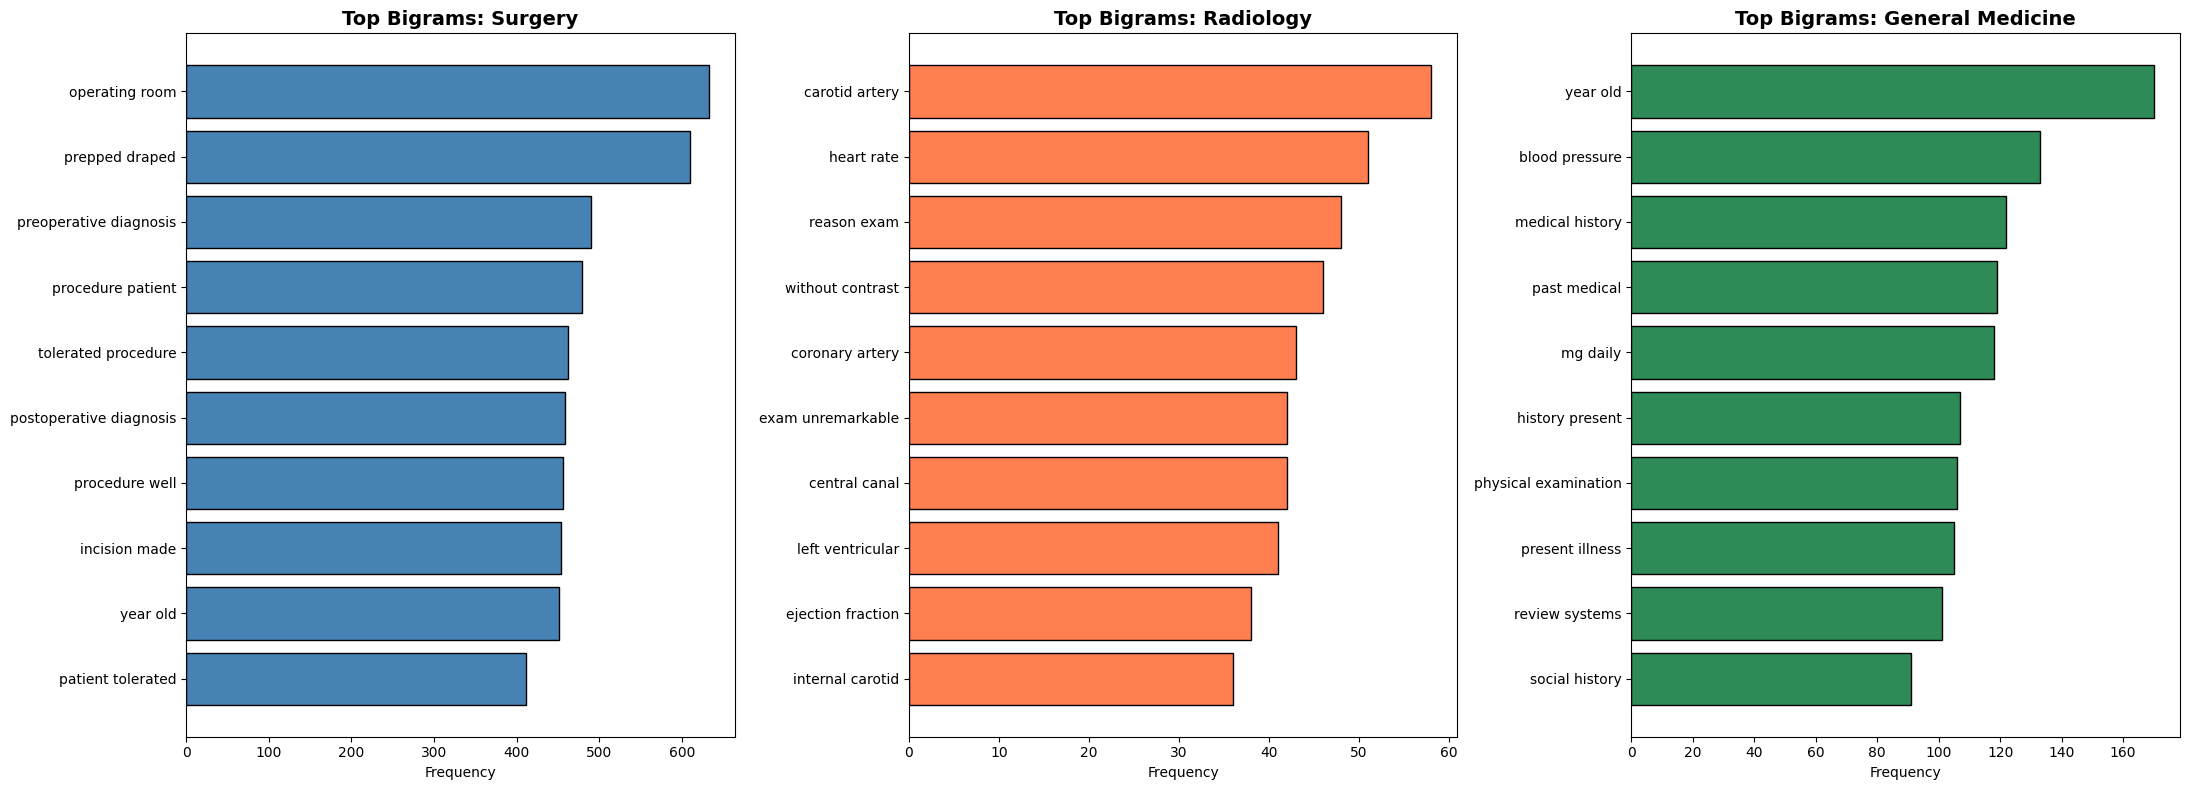

In [405]:
# Bigrams (2-Word Phrases) Overall
print("Top 20 Bigrams (Overall)")
print("-"*50)
all_bigrams = []
for words in df["processed_words"]:
    if len(words) >= 2:
        bigrams_list = list(ngrams(words, 2))
        all_bigrams.extend(bigrams_list)
bigrams_counter = Counter(all_bigrams)
top_20_bigrams = bigrams_counter.most_common(20)
for bigram, count in top_20_bigrams:
    print(f"{' '.join(bigram):30s}: {count:,}")

plt.figure(figsize=(8, 6))
bigram_labels = [" ".join(bg) for bg, _ in top_20_bigrams]
bigram_counts = [count for _, count in top_20_bigrams]
plt.barh(bigram_labels, bigram_counts, color="steelblue", edgecolor="black")
plt.title("Top 20 Bigrams (Overall)", fontsize=16, fontweight="bold")
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Bigrams", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Bigrams Per Specialty
print("Top 10 Bigrams Per Specialty")
print("-"*50)
for specialty in specialties[:3]:
    print("\n")
    print(f"{specialty.strip()}")
    print(f"{'-'*50}")
    specialty_bigrams = []
    for words in df[df["medical_specialty"] == specialty]["processed_words"]:
        if len(words) >= 2:
            bigrams_list = list(ngrams(words, 2))
            specialty_bigrams.extend(bigrams_list)
    specialty_bigrams_counter = Counter(specialty_bigrams)
    for bigram, count in specialty_bigrams_counter.most_common(10):
        print(f"{' '.join(bigram):30s}: {count:,}")

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for idx, specialty in enumerate(specialties[:3]):
    specialty_bigrams = []
    for words in df[df["medical_specialty"] == specialty]["processed_words"]:
        if len(words) >= 2:
            bigrams_list = list(ngrams(words, 2))
            specialty_bigrams.extend(bigrams_list)
    specialty_bigrams_counter = Counter(specialty_bigrams)
    top_bigrams = specialty_bigrams_counter.most_common(10)
    bigram_labels = [" ".join(bg) for bg, _ in top_bigrams]
    bigram_counts = [count for _, count in top_bigrams]
    axes[idx].barh(bigram_labels, bigram_counts, color=colors[idx], edgecolor="black")
    axes[idx].set_title(f"Top Bigrams: {specialty}", fontsize=14, fontweight="bold")
    axes[idx].set_xlabel("Frequency", fontsize=10)
    axes[idx].invert_yaxis()
plt.tight_layout()
plt.show()


Top 20 Trigrams (Overall)
--------------------------------------------------
tolerated procedure well                : 506
past medical history                    : 483
history present illness                 : 476
patient tolerated procedure             : 452
prepped draped usual                    : 379
estimated blood loss                    : 356
year old female                         : 306
taken operating room                    : 274
present illness patient                 : 247
draped usual sterile                    : 235
within normal limits                    : 235
patient taken operating                 : 221
regular rate rhythm                     : 209
coronary artery disease                 : 204
year old male                           : 202
past surgical history                   : 190
operating room placed                   : 181
usual sterile fashion                   : 181
informed consent obtained               : 180
examination vital signs                 : 180


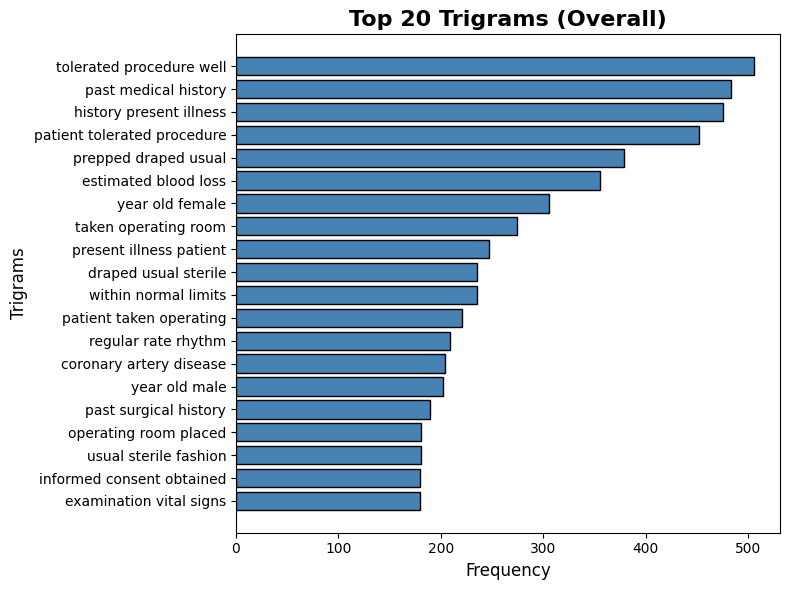

Top 10 Trigrams Per Specialty
--------------------------------------------------


Surgery
--------------------------------------------------
tolerated procedure well                : 424
patient tolerated procedure             : 382
prepped draped usual                    : 337
estimated blood loss                    : 313
taken operating room                    : 219
draped usual sterile                    : 206
patient taken operating                 : 185
operating room placed                   : 163
patient brought operating               : 162
brought operating room                  : 161


Radiology
--------------------------------------------------
internal carotid artery                 : 32
within normal limits                    : 27
person place time                       : 27
illicit drug use                        : 22
ms person place                         : 21
beats per minute                        : 20
axial ct images                         : 19
plantar responses fl

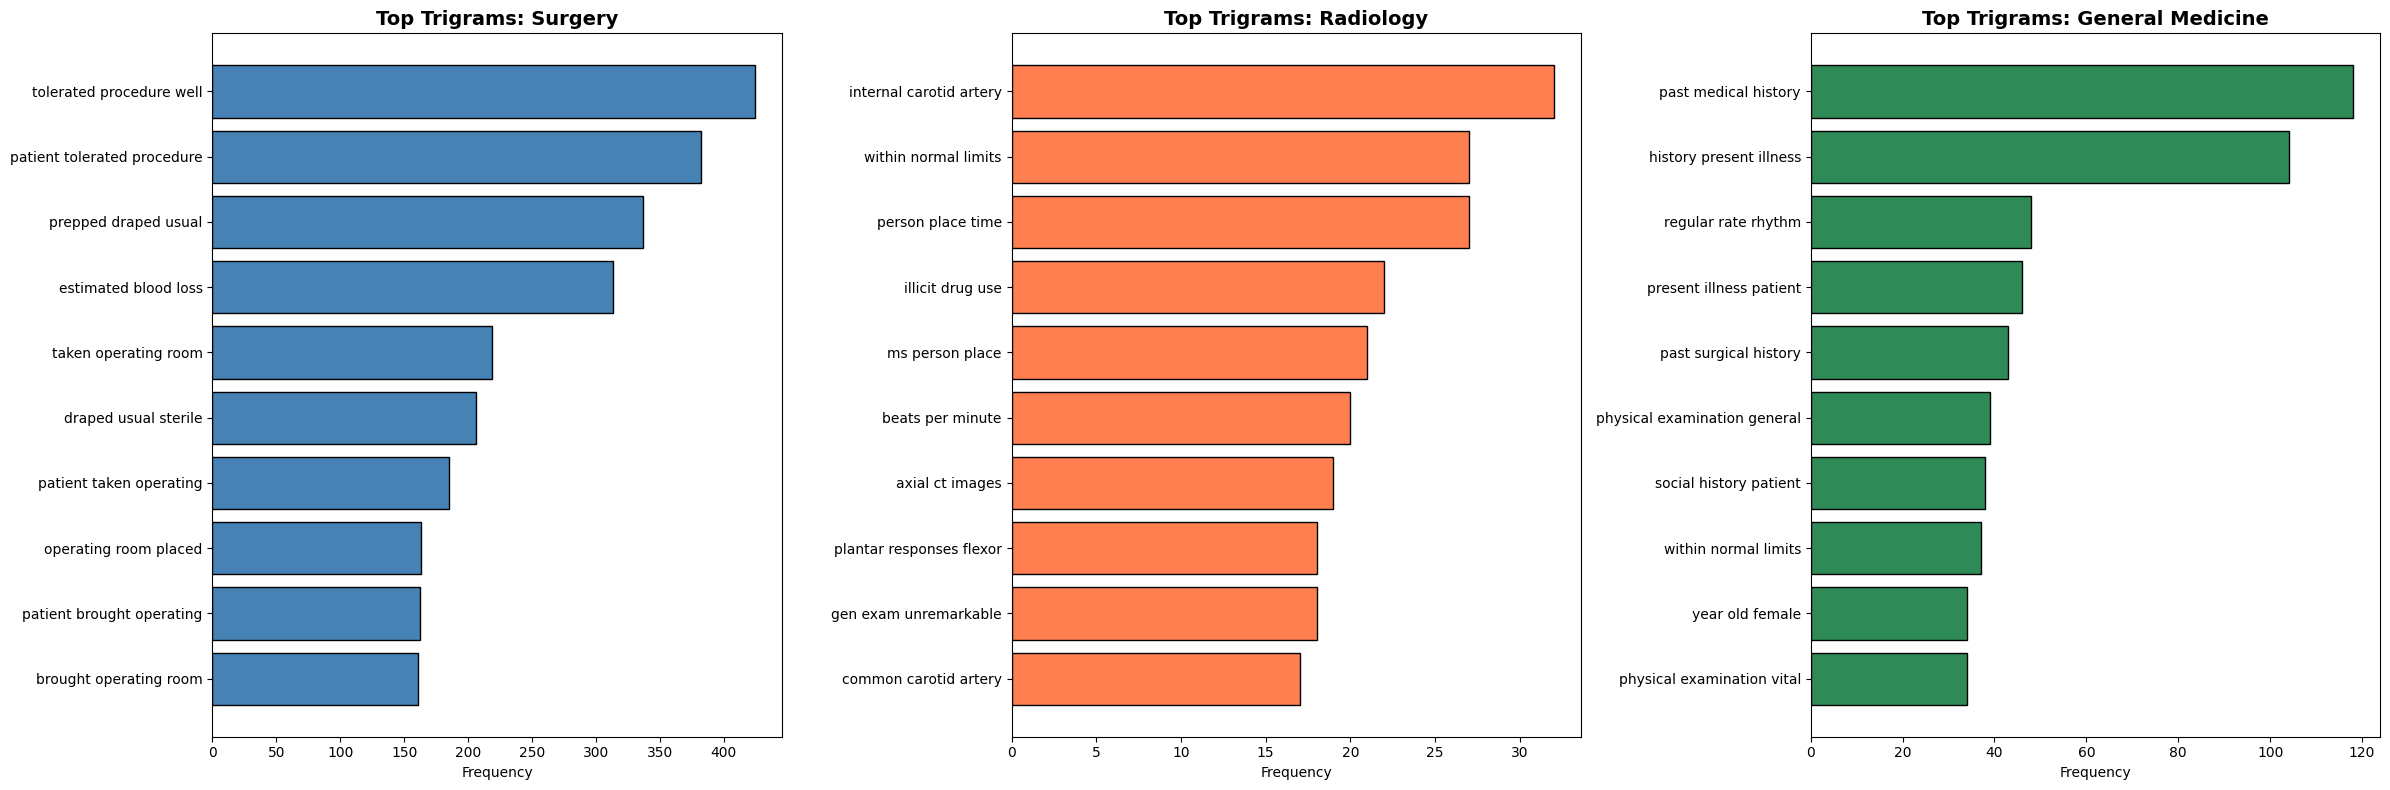

In [406]:
# Trigrams (3-Word Phrases) - Overall
print("Top 20 Trigrams (Overall)")
print("-"*50)
all_trigrams = []
for words in df["processed_words"]:
    if len(words) >= 3:
        trigrams_list = list(ngrams(words, 3))
        all_trigrams.extend(trigrams_list)
trigrams_counter = Counter(all_trigrams)
top_20_trigrams = trigrams_counter.most_common(20)
for trigram, count in top_20_trigrams:
    print(f"{' '.join(trigram):40s}: {count:,}")

plt.figure(figsize=(8, 6))
trigram_labels = [" ".join(tg) for tg, _ in top_20_trigrams]
trigram_counts = [count for _, count in top_20_trigrams]
plt.barh(trigram_labels, trigram_counts, color="steelblue", edgecolor="black")
plt.title("Top 20 Trigrams (Overall)", fontsize=16, fontweight="bold")
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Trigrams", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Trigrams Per Specialty
print("Top 10 Trigrams Per Specialty")
print("-"*50)
for specialty in specialties[:3]:
    print("\n")
    print(f"{specialty.strip()}")
    print(f"{'-'*50}")
    specialty_trigrams = []
    for words in df[df["medical_specialty"] == specialty]["processed_words"]:
        if len(words) >= 3:
            trigrams_list = list(ngrams(words, 3))
            specialty_trigrams.extend(trigrams_list)
    specialty_trigrams_counter = Counter(specialty_trigrams)
    for trigram, count in specialty_trigrams_counter.most_common(10):
        print(f"{' '.join(trigram):40s}: {count:,}")

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for idx, specialty in enumerate(specialties[:3]):
    specialty_trigrams = []
    for words in df[df["medical_specialty"] == specialty]["processed_words"]:
        if len(words) >= 3:
            trigrams_list = list(ngrams(words, 3))
            specialty_trigrams.extend(trigrams_list)
    specialty_trigrams_counter = Counter(specialty_trigrams)
    top_trigrams = specialty_trigrams_counter.most_common(10)
    trigram_labels = [" ".join(bg) for bg, _ in top_trigrams]
    trigram_counts = [count for _, count in top_trigrams]
    axes[idx].barh(trigram_labels, trigram_counts, color=colors[idx], edgecolor="black")
    axes[idx].set_title(f"Top Trigrams: {specialty}", fontsize=14, fontweight="bold")
    axes[idx].set_xlabel("Frequency", fontsize=10)
    axes[idx].invert_yaxis()
plt.tight_layout()
plt.show()

### Phase 2 - Statistical Significance & Linguistic Importance

In [407]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

#### Chi-Square Test for Term Independence

* Null Hypothesis ($H_0$): The occurrence of a specific term (e.g., "Artery") is independent of the medical specialty.
* Alternative Hypothesis ($H_1$): The term and the specialty are highly dependent.


Document-Term Matrix:
Number of documents: 2351
Number of unique terms: 5000

Number of specialties: 39
Specialties: ['Allergy / Immunology', 'Autopsy', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Chiropractic', 'Consult - History and Phy.', 'Cosmetic / Plastic Surgery', 'Dentistry', 'Dermatology', 'Discharge Summary']...

Top 20 Terms with the Highest Chi-Square Scores
--------------------------------------------------
Term                 Chi2 Score      P-Value        
--------------------------------------------------
acne                 12793.31        0.00e+00       
nodosum              11735.00        0.00e+00       
inch                 5990.12         0.00e+00       
petechial            5869.61         0.00e+00       
mr                   5267.22         0.00e+00       
history              5257.49         0.00e+00       
contains             4517.41         0.00e+00       
grams                4404.57         0.00e+00       
ligature             4236.12         0.00e+00 

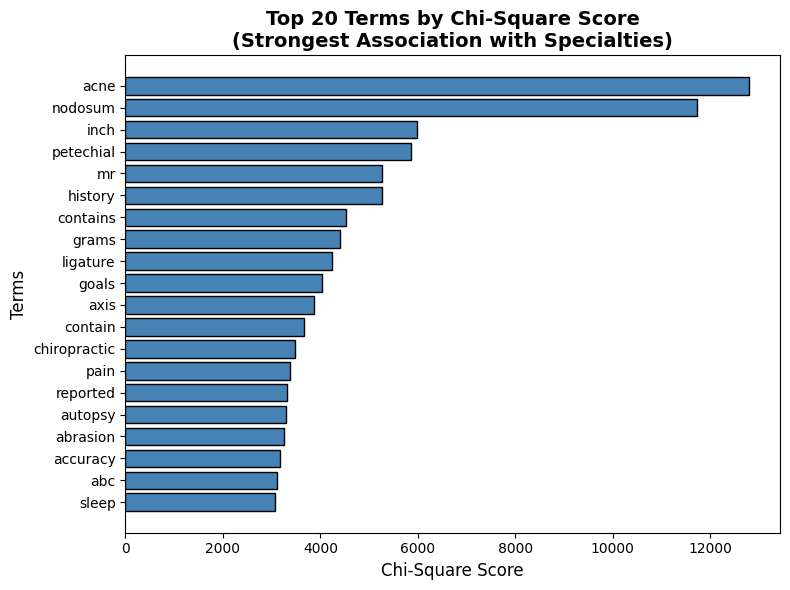

In [408]:
# Instead of testing length, we test if specific words are statistically "locked" to a specialty
df["processed_text"] = df["processed_words"].apply(lambda x: " ".join(x))
vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 1)) # only unigrams for now
X = vectorizer.fit_transform(df["processed_text"])
feature_names = vectorizer.get_feature_names_out()
print(f"\nDocument-Term Matrix:")
print(f"Number of documents: {X.shape[0]}")
print(f"Number of unique terms: {X.shape[1]}")


y = df["medical_specialty"]
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"\nNumber of specialties: {len(label_encoder.classes_)}")
print(f"Specialties: {list(label_encoder.classes_[:10])}...")

chi2_scores, p_values = chi2(X, y_encoded)
chi2_results = pd.DataFrame({
    "term": feature_names,
    "chi2_score": chi2_scores,
    "p_value": p_values
})
chi2_results = chi2_results.sort_values("chi2_score", ascending=False)

print("\nTop 20 Terms with the Highest Chi-Square Scores")
print("-"*50)
print(f"{'Term':<20} {'Chi2 Score':<15} {'P-Value':<15}")
print("-"*50)
for idx, row in chi2_results.head(20).iterrows(): # Show all terms to see different p-values
    print(f"{row['term']:<20} {row['chi2_score']:<15.2f} {row['p_value']:<15.2e}")

plt.figure(figsize=(8, 6))
top_20_chi2 = chi2_results.head(20)
plt.barh(top_20_chi2["term"], top_20_chi2["chi2_score"], color="steelblue", edgecolor="black")
plt.xlabel("Chi-Square Score", fontsize=12)
plt.ylabel("Terms", fontsize=12)
plt.title("Top 20 Terms by Chi-Square Score\n(Strongest Association with Specialties)", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### N-Gram Analysis


Total words in corpus: 656,450
Unique words: 22,358

Total bigrams: 654,099
Unique bigrams: 328,082

Top 30 Bigrams By PMI Score
------------------------------------------------------------
Bigram                              Count      PMI Score   
------------------------------------------------------------
passy muir                          10         16.01       
indigo carmine                      11         15.87       
swan ganz                           10         15.63       
botulinum toxin                     10         15.42       
gore tex                            15         15.33       
neo synephrine                      11         15.33       
domestic violence                   10         15.19       
carpi radialis                      11         15.18       
gluteus maximus                     10         15.16       
tonic clonic                        11         15.12       
carbon dioxide                      17         14.94       
ligamentum flavum           

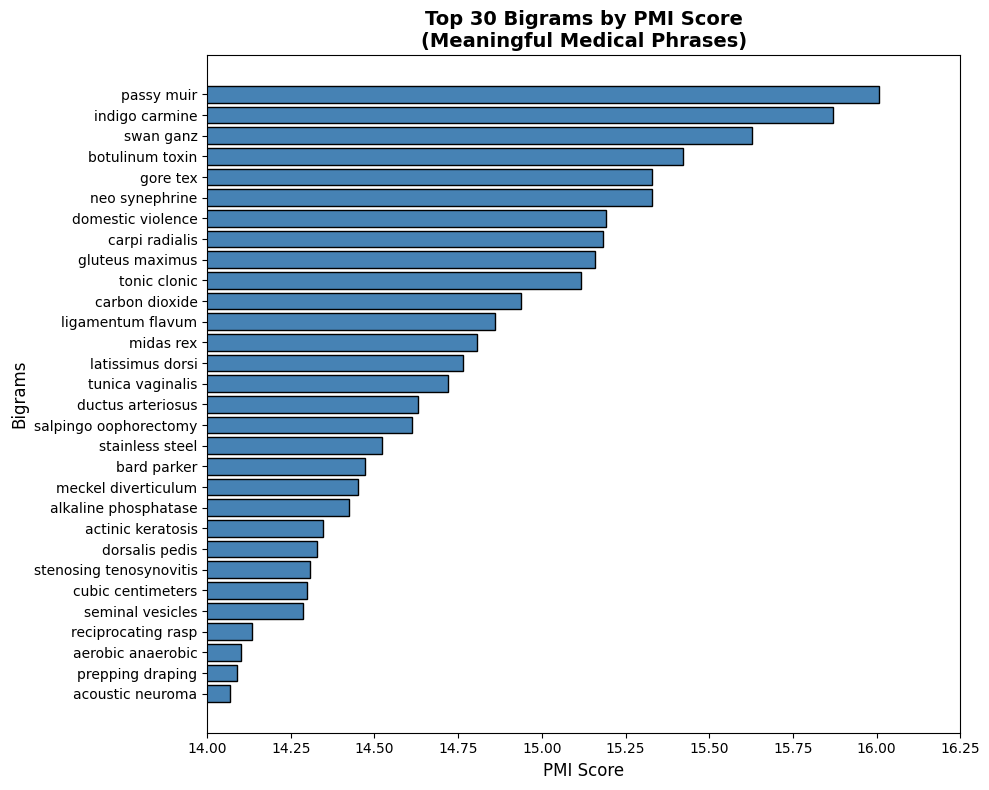

In [409]:
total_words = len(all_words)
print(f"\nTotal words in corpus: {total_words:,}")
print(f"Unique words: {len(word_freq):,}")

total_bigrams = len(all_bigrams)
print(f"\nTotal bigrams: {total_bigrams:,}")
print(f"Unique bigrams: {len(bigrams_counter):,}")

pmi_scores = []
for bigram, bigram_count in bigrams_counter.items():
    if bigram_count < 10:
        continue
    word1, word2 = bigram
    p_bigram = bigram_count / total_bigrams
    p_word1 = word_freq[word1] / total_words
    p_word2 = word_freq[word2] / total_words
    # PMI score to find words that occur together more often than they would by random chance ("Range of Motion" vs. "The Patient")
    # PMI = log2(P(word1, word2) / (P(word1) * P(word2)))
    pmi = np.log2(p_bigram / (p_word1 * p_word2))
    pmi_scores.append({
        "bigram": " ".join(bigram),
        "count": bigram_count,
        "pmi": pmi
    })

bi_pmi_df = pd.DataFrame(pmi_scores)
bi_pmi_df = bi_pmi_df.sort_values("pmi", ascending=False)

print("\nTop 30 Bigrams By PMI Score")
print("-"*60)
print(f"{'Bigram':<35} {'Count':<10} {'PMI Score':<12}")
print("-"*60)
for idx, row in bi_pmi_df.head(30).iterrows():
    print(f"{row['bigram']:<35} {row['count']:<10} {row['pmi']:<12.2f}")

plt.figure(figsize=(10, 8))
bi_top_30_pmi = bi_pmi_df.head(30)
plt.barh(bi_top_30_pmi["bigram"], bi_top_30_pmi["pmi"], color="steelblue", edgecolor="black")
plt.xlabel("PMI Score", fontsize=12)
plt.ylabel("Bigrams", fontsize=12)
plt.xlim(14, 16.25)
plt.title("Top 30 Bigrams by PMI Score\n(Meaningful Medical Phrases)", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Total trigrams: 651,748
Unique trigrams: 509,783

Top 30 Trigrams By PMI Score
------------------------------------------------------------------------------------------
Trigram                                                      Count      PMI Score   
------------------------------------------------------------------------------------------
flexor carpi radialis                                        10         27.50       
fast absorbing gut                                           10         27.18       
adaptic 4x4s abds                                            11         27.12       
midas rex drill                                              12         26.80       
immediate hyperemic flush                                    15         26.73       
orthopnea paroxysmal nocturnal                               15         26.44       
herniated nucleus pulposus                                   34         26.06       
paroxysmal nocturnal dyspnea                              

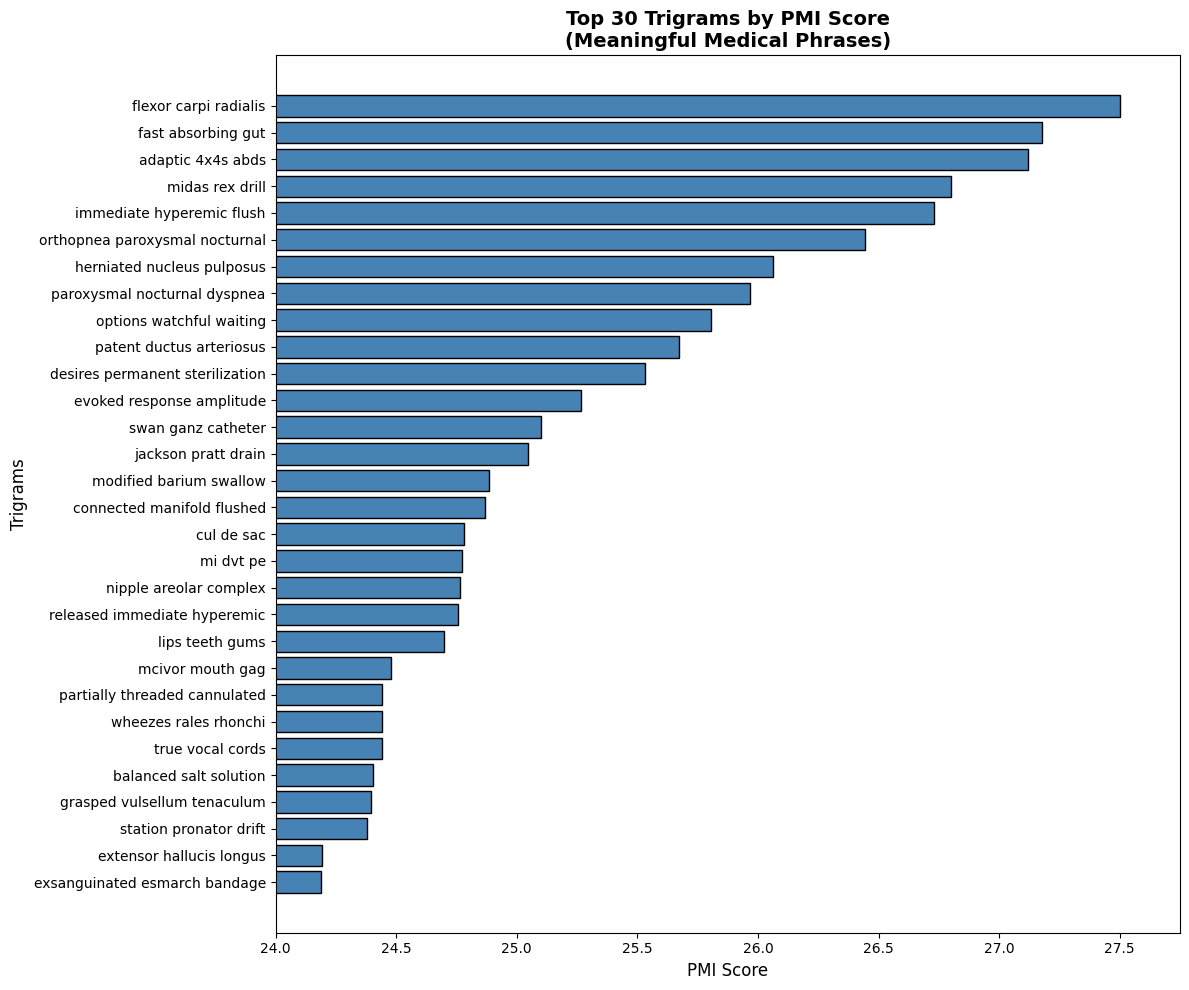

In [410]:
total_trigrams = len(all_trigrams)
print(f"\nTotal trigrams: {total_trigrams:,}")
print(f"Unique trigrams: {len(trigrams_counter):,}")

pmi_scores = []
for trigram, trigram_count in trigrams_counter.items():
    if trigram_count < 10:
        continue
    word1, word2, word3 = trigram
    p_trigram = trigram_count / total_trigrams
    p_word1 = word_freq[word1] / total_words
    p_word2 = word_freq[word2] / total_words
    p_word3 = word_freq[word3] / total_words
    # PMI score to find words that occur together more often than they would by random chance ("Range of Motion" vs. "The Patient")
    # PMI = log2(P(word1, word2, word3) / (P(word1) * P(word2) * P(word3)))
    pmi = np.log2(p_trigram / (p_word1 * p_word2 * p_word3))
    pmi_scores.append({
        "trigram": " ".join(trigram),
        "count": trigram_count,
        "pmi": pmi
    })

tri_pmi_df = pd.DataFrame(pmi_scores)
tri_pmi_df = tri_pmi_df.sort_values("pmi", ascending=False)

print("\nTop 30 Trigrams By PMI Score")
print("-"*90)
print(f"{'Trigram':<60} {'Count':<10} {'PMI Score':<12}")
print("-"*90)
for idx, row in tri_pmi_df.head(30).iterrows():
    print(f"{row['trigram']:<60} {row['count']:<10} {row['pmi']:<12.2f}")

plt.figure(figsize=(12, 10))
tri_top_30_pmi = tri_pmi_df.head(30)
plt.barh(tri_top_30_pmi["trigram"], tri_top_30_pmi["pmi"], color="steelblue", edgecolor="black")
plt.xlabel("PMI Score", fontsize=12)
plt.ylabel("Trigrams", fontsize=12)
plt.xlim(24, 27.75)
plt.title("Top 30 Trigrams by PMI Score\n(Meaningful Medical Phrases)", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Term Frequency - Inverse Document Frequency

In [411]:
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict

TF-IDF Matrix Shape:
Number of documents: 2351
Number of unique terms: 5000

Top TF-IDF Terms Per Specialty
------------------------------------------------------------

Surgery
------------------------------------------------------------
Term                      Avg TF-IDF     
----------------------------------------
patient                   0.0618         
procedure                 0.0602         
placed                    0.0488         
left                      0.0471         
right                     0.0465         
anesthesia                0.0340         
incision                  0.0329         
using                     0.0317         
removed                   0.0311         
diagnosis                 0.0298         

Radiology
------------------------------------------------------------
Term                      Avg TF-IDF     
----------------------------------------
normal                    0.0565         
left                      0.0525         
right              

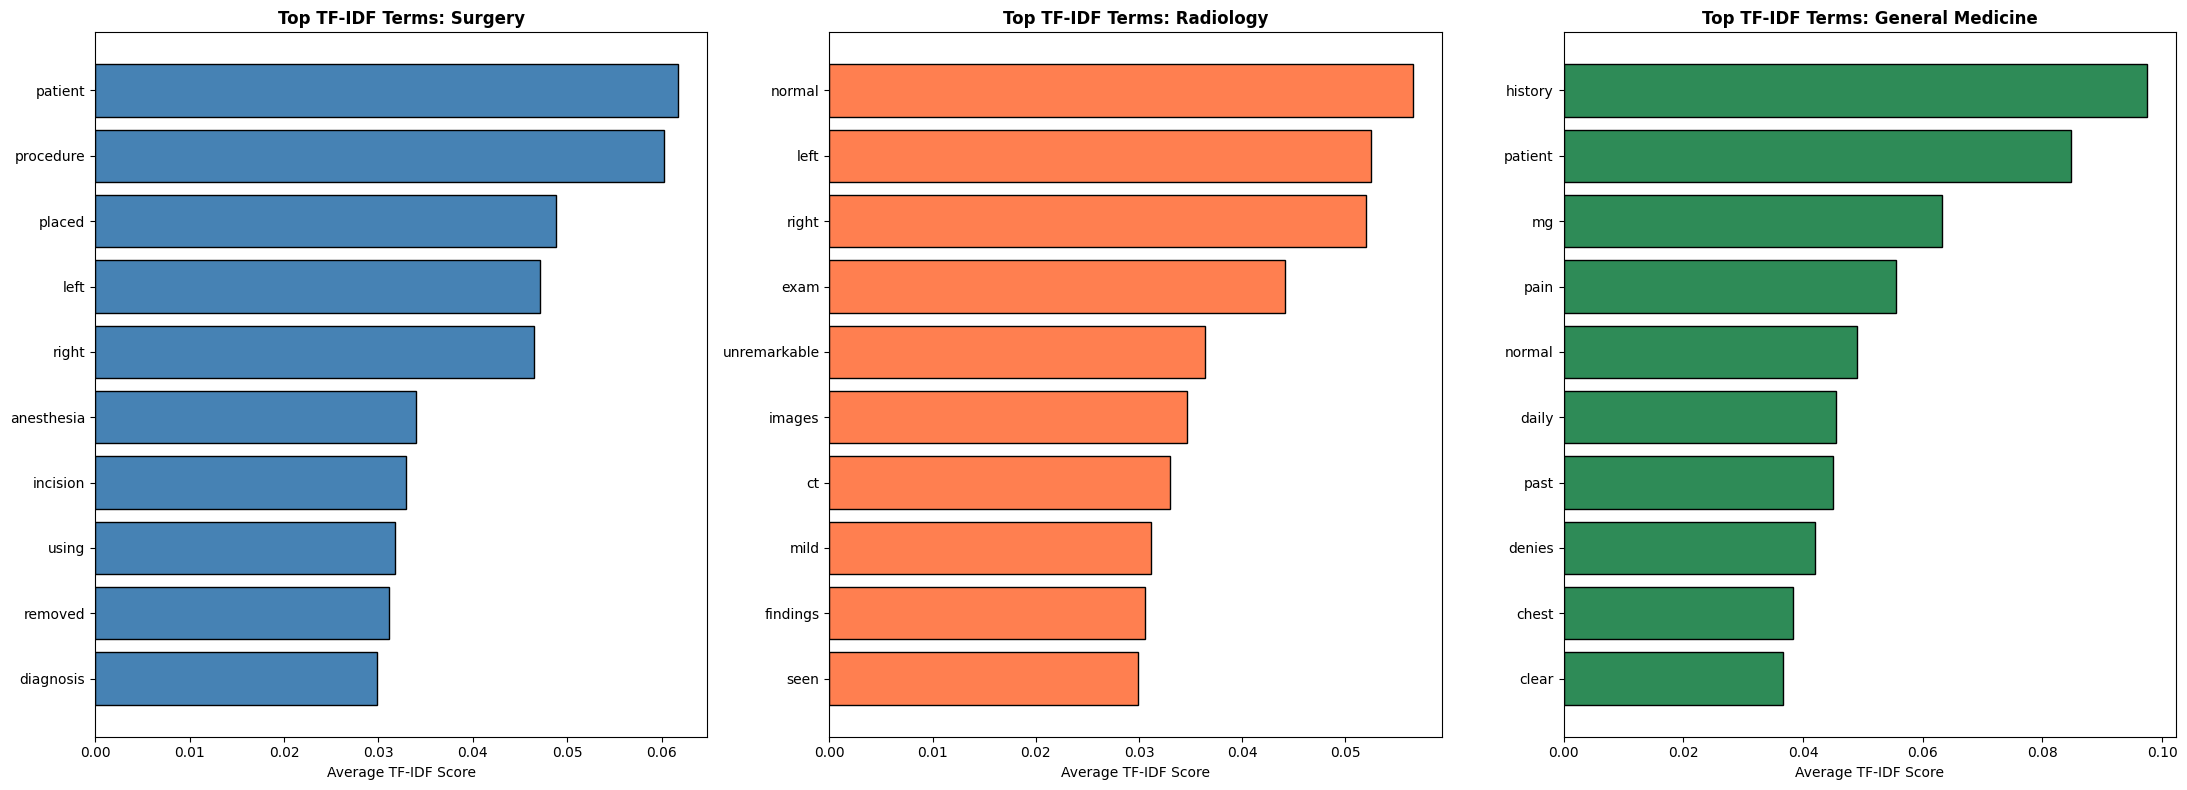

In [412]:
# Term Frequency: "How much does Cardiology talk about Stents?"
# Inverse Document Frequency: "Does everyone else talk about Stents too?"
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1), # capture unigrams
    min_df=2, # account for typos/rare words
    max_df=0.95 # account for overly frequent words
)
X_tfidf = vectorizer.fit_transform(df["processed_text"])
feature_names = vectorizer.get_feature_names_out()
print("TF-IDF Matrix Shape:")
print(f"Number of documents: {X_tfidf.shape[0]}")
print(f"Number of unique terms: {X_tfidf.shape[1]}")

print("\nTop TF-IDF Terms Per Specialty")
print("-"*60)
specialty_top_terms = {}
for specialty in specialties:
    print(f"\n{specialty.strip()}")
    print(f"{'-'*60}")
    specialty_indices = df[df["medical_specialty"] == specialty].index
    specialty_tfidf = X_tfidf[specialty_indices]
    specialty_mean_tfidf = np.asarray(specialty_tfidf.mean(axis=0)).flatten()
    specialty_tfidf_df = pd.DataFrame({
        "term": feature_names,
        "tfidf": specialty_mean_tfidf
    }).sort_values("tfidf", ascending=False)
    specialty_top_terms[specialty] = specialty_tfidf_df.head(10)
    print(f"{'Term':<25} {'Avg TF-IDF':<15}")
    print("-"*40)
    for idx, row in specialty_tfidf_df.head(10).iterrows():
        print(f"{row['term']:<25} {row['tfidf']:<15.4f}")

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for idx, specialty in enumerate(specialties[:3]):
    top_terms = specialty_top_terms[specialty].head(10)
    axes[idx].barh(top_terms["term"], top_terms["tfidf"], color=colors[idx], edgecolor="black")
    axes[idx].set_title(f"Top TF-IDF Terms: {specialty}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Average TF-IDF Score", fontsize=10)
    axes[idx].invert_yaxis()
plt.tight_layout()
plt.show()

### Phase 3 - Machine Learning & Classification

In [413]:
from sklearn.model_selection import train_test_split

#### Data Preparation Pipeline

In [414]:
# problematic_classes = ["Office Notes", "Discharge Summary"]
# df = df[~df["medical_specialty"].isin(problematic_classes)] ## Uncomment if certain classes cause problems with performance
X = df["transcription"]
y = df["medical_specialty"]
print(f"Number of samples: {len(X)}")
print(f"Number of classes: {y.nunique()}")
print(f"\nSmallest class size: {y.value_counts().min()}")
print(f"Largest class size: {y.value_counts().max()}")

print("\nClass Distribution")
print("-"*60)
print(f"{'Specialty':<35} {'Count':<10} {'Percentage':<10}")
print("-"*60)
specialty_counts = y.value_counts()
for specialty, count in specialty_counts.items():
    percentage = (count / len(y)) * 100
    print(f"{specialty:<35} {count:<10} {percentage:<4.2f}%")

Number of samples: 2351
Number of classes: 39

Smallest class size: 1
Largest class size: 975

Class Distribution
------------------------------------------------------------
Specialty                           Count      Percentage
------------------------------------------------------------
Surgery                             975        41.47%
Radiology                           247        10.51%
General Medicine                    157        6.68%
Urology                             155        6.59%
SOAP / Chart / Progress Notes       143        6.08%
Neurology                           67         2.85%
Orthopedic                          55         2.34%
Consult - History and Phy.          55         2.34%
Pediatrics - Neonatal               52         2.21%
Psychiatry / Psychology             51         2.17%
Pain Management                     44         1.87%
Office Notes                        41         1.74%
Hematology - Oncology               31         1.32%
Gastroenterolog

In [415]:
# Stratified Train/Test Split (80/20)
# Filter out classes with very few samples (can increase minimum if needed)
class_counts = pd.Series(y).value_counts()
valid_classes = class_counts[class_counts >= 10].index # counter large class imbalance / ensure classes have ample samples in both train/test sets
mask = y.isin(valid_classes)
X_filtered = X[mask]
y_filtered = y[mask]
X_filtered = X_filtered.reset_index(drop=True)
y_filtered = y_filtered.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered # stratify ensures rare specialties are accounted for
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining class distribution (top 5):")
print(y_train.value_counts().head())
print(f"\nTest class distribution (top 5):")
print(y_test.value_counts().head())

Training set size: 1830
Test set size: 458

Training class distribution (top 5):
medical_specialty
Surgery                          780
Radiology                        197
General Medicine                 125
Urology                          124
SOAP / Chart / Progress Notes    114
Name: count, dtype: int64

Test class distribution (top 5):
medical_specialty
Surgery                          195
Radiology                         50
General Medicine                  32
Urology                           31
SOAP / Chart / Progress Notes     29
Name: count, dtype: int64


Training matrix shape:
  - Number of documents: 1830
  - Number of features: 10000

Test matrix shape:
  - Number of documents: 458
  - Number of features: 10000

Feature Analysis: N-Gram Distribution
------------------------------------------------------------
Unigrams: 5140 (51.4%)
Bigrams: 3747 (37.5%)
Trigrams: 1113 (11.1%)


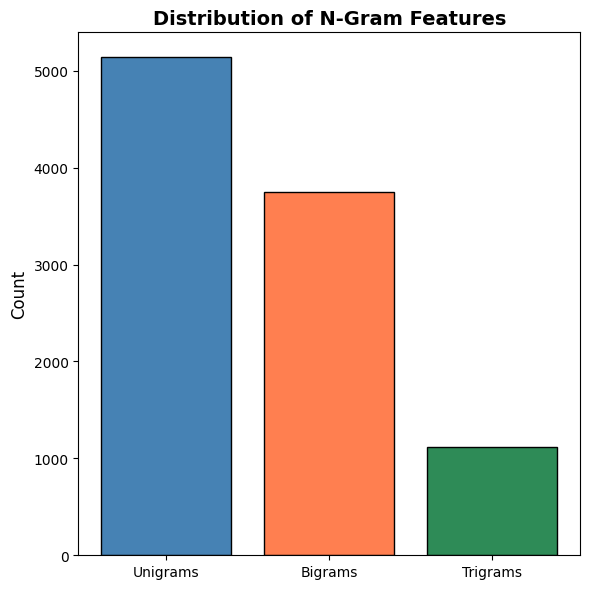

In [416]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 3), # capture uni/bi/trigrams
    stop_words="english", # account for stopwords
    min_df=2, # account for typos/rare words
    max_df=0.95, # account for overly frequent words
    sublinear_tf=True
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
feature_names = vectorizer.get_feature_names_out()
print("Training matrix shape:")
print(f"  - Number of documents: {X_train_tfidf.shape[0]}")
print(f"  - Number of features: {X_train_tfidf.shape[1]}")
print("\nTest matrix shape:")
print(f"  - Number of documents: {X_test_tfidf.shape[0]}")
print(f"  - Number of features: {X_test_tfidf.shape[1]}")

print("\nFeature Analysis: N-Gram Distribution")
print("-"*60)
unigrams = [f for f in feature_names if len(f.split()) == 1]
bigrams = [f for f in feature_names if len(f.split()) == 2]
trigrams = [f for f in feature_names if len(f.split()) == 3]
print(f"Unigrams: {len(unigrams)} ({len(unigrams)/len(feature_names)*100:.1f}%)")
print(f"Bigrams: {len(bigrams)} ({len(bigrams)/len(feature_names)*100:.1f}%)")
print(f"Trigrams: {len(trigrams)} ({len(trigrams)/len(feature_names)*100:.1f}%)")

ngram_counts = [len(unigrams), len(bigrams), len(trigrams)]
ngram_labels = ["Unigrams", "Bigrams", "Trigrams"]
plt.figure(figsize=(6, 6))
plt.bar(ngram_labels, ngram_counts, color=["steelblue", "coral", "seagreen"], edgecolor="black")
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of N-Gram Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Model Training

In [417]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

In [ ]:
# Linear Support Vector Classification (see performance against other models)
# Helpful for classifying, works well in high-dimensional spaces
start_time = time.time()
sv_model = LinearSVC(
    class_weight="balanced",
    max_iter=1000,
    C=1, # regularization parameter
    random_state=42
)
sv_model.fit(X_train_tfidf, y_train)
sv_train_time = time.time() - start_time

start_time = time.time()
y_pred_sv = sv_model.predict(X_test_tfidf)
sv_predict_time = time.time() - start_time
y_pred_sv_train = sv_model.predict(X_train_tfidf)

sv_train_accuracy = accuracy_score(y_train, y_pred_sv_train)
sv_test_accuracy = accuracy_score(y_test, y_pred_sv)
print(f"Linear SVC Results:")
print(f"  Training time: {sv_train_time:.4f} seconds")
print(f"  Prediction time: {sv_predict_time:.4f} seconds")
print(f"  Test Accuracy: {sv_test_accuracy:.4f}")
print(f"  (Training Accuracy: {sv_train_accuracy:.4f})")

Linear SVC Results:
  Training time: 0.1446 seconds
  Prediction time: 0.0008 seconds
  Test Accuracy: 0.8297
  (Training Accuracy: 0.9945)


In [419]:
# Logistic Regression (Linear Baseline)
# Fast and provides coefficients to see which words are driving a prediction
start_time = time.time()
lr_model = LogisticRegression(
    class_weight="balanced", # help model not ignore smaller specialties
    max_iter=1000,
    C=2,
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)
lr_train_time = time.time() - start_time

start_time = time.time()
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_predict_time = time.time() - start_time
y_pred_lr_train = lr_model.predict(X_train_tfidf)

lr_train_accuracy= accuracy_score(y_train, y_pred_lr_train)
lr_test_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Results:")
print(f"   Training time: {lr_train_time:.4f} seconds")
print(f"   Prediction time: {lr_predict_time:.4f} seconds")
print(f"   Test Accuracy: {lr_test_accuracy:.4f}")
print(f"   (Training Accuracy: {lr_train_accuracy:.4f})")

Logistic Regression Results:
   Training time: 0.6176 seconds
   Prediction time: 0.0009 seconds
   Test Accuracy: 0.8122
   (Training Accuracy: 0.9645)


In [420]:
# Multinomial Naive Bayes (Text Specialist)
# Assumes feature independence which works surprisingly well for "bag-of-words" models, extremely robust against high-dimensional noise
start_time = time.time()
nb_model = MultinomialNB(
    alpha=1.0  # Laplace smoothing (default)
)
nb_model.fit(X_train_tfidf, y_train)
nb_train_time = time.time() - start_time

start_time = time.time()
y_pred_nb = nb_model.predict(X_test_tfidf)
nb_predict_time = time.time() - start_time
y_pred_nb_train = nb_model.predict(X_train_tfidf)

nb_train_accuracy = accuracy_score(y_train, y_pred_nb_train)
nb_test_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Multinomial Naive Bayes Results:")
print(f"   Training time: {nb_train_time:.4f} seconds")
print(f"   Prediction time: {nb_predict_time:.4f} seconds")
print(f"   Test Accuracy: {nb_test_accuracy:.4f}")
print(f"   (Training Accuracy: {nb_train_accuracy:.4f})")

Multinomial Naive Bayes Results:
   Training time: 0.0112 seconds
   Prediction time: 0.0009 seconds
   Test Accuracy: 0.6201
   (Training Accuracy: 0.6519)


In [421]:
# Random Forest (Non-Linear Option)
# Are there complex, non-linear relationships?
start_time = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    verbose=0
)
rf_model.fit(X_train_tfidf, y_train)
rf_train_time = time.time() - start_time

start_time = time.time()
y_pred_rf = rf_model.predict(X_test_tfidf)
rf_predict_time = time.time() - start_time
y_pred_rf_train = rf_model.predict(X_train_tfidf)

rf_train_accuracy = accuracy_score(y_train, y_pred_rf_train)
rf_test_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Results:")
print(f"   Training time: {rf_train_time:.4f} seconds")
print(f"   Prediction time: {rf_predict_time:.4f} seconds")
print(f"   Test Accuracy: {rf_test_accuracy:.4f}")
print(f"   (Training Accuracy: {rf_train_accuracy:.4f})")

Random Forest Results:
   Training time: 0.6215 seconds
   Prediction time: 0.0113 seconds
   Test Accuracy: 0.7555
   (Training Accuracy: 0.9923)


#### Evaluation & Model Comparison

In [422]:
from sklearn.metrics import confusion_matrix, f1_score

In [423]:
# Linear SVC
sv_accuracy = accuracy_score(y_test, y_pred_sv)
sv_macro_f1 = f1_score(y_test, y_pred_sv, average="macro")
sv_weighted_f1 = f1_score(y_test, y_pred_sv, average="weighted")
# Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_macro_f1 = f1_score(y_test, y_pred_lr, average="macro")
lr_weighted_f1 = f1_score(y_test, y_pred_lr, average="weighted")
# Naive Bayes
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_macro_f1 = f1_score(y_test, y_pred_nb, average="macro")
nb_weighted_f1 = f1_score(y_test, y_pred_nb, average="weighted")
# Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")
rf_weighted_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Linear SVC")
print(f"  Accuracy: {sv_accuracy:.4f}")
print(f"  Macro F1: {sv_macro_f1:.4f}")
print(f"  Weighted F1: {sv_weighted_f1:.4f}\n")
print("Logistic Regression")
print(f"  Accuracy: {lr_accuracy:.4f}")
print(f"  Macro F1: {lr_macro_f1:.4f}")
print(f"  Weighted F1: {lr_weighted_f1:.4f}\n")
print("Naive Bayes")
print(f"  Accuracy: {nb_accuracy:.4f}")
print(f"  Macro F1: {nb_macro_f1:.4f}")
print(f"  Weighted F1: {nb_weighted_f1:.4f}\n")
print("Random Forest")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  Macro F1: {rf_macro_f1:.4f}")
print(f"  Weighted F1: {rf_weighted_f1:.4f}")


Linear SVC
  Accuracy: 0.8297
  Macro F1: 0.6663
  Weighted F1: 0.8266

Logistic Regression
  Accuracy: 0.8122
  Macro F1: 0.6648
  Weighted F1: 0.8129

Naive Bayes
  Accuracy: 0.6201
  Macro F1: 0.1317
  Weighted F1: 0.5411

Random Forest
  Accuracy: 0.7555
  Macro F1: 0.4987
  Weighted F1: 0.7350


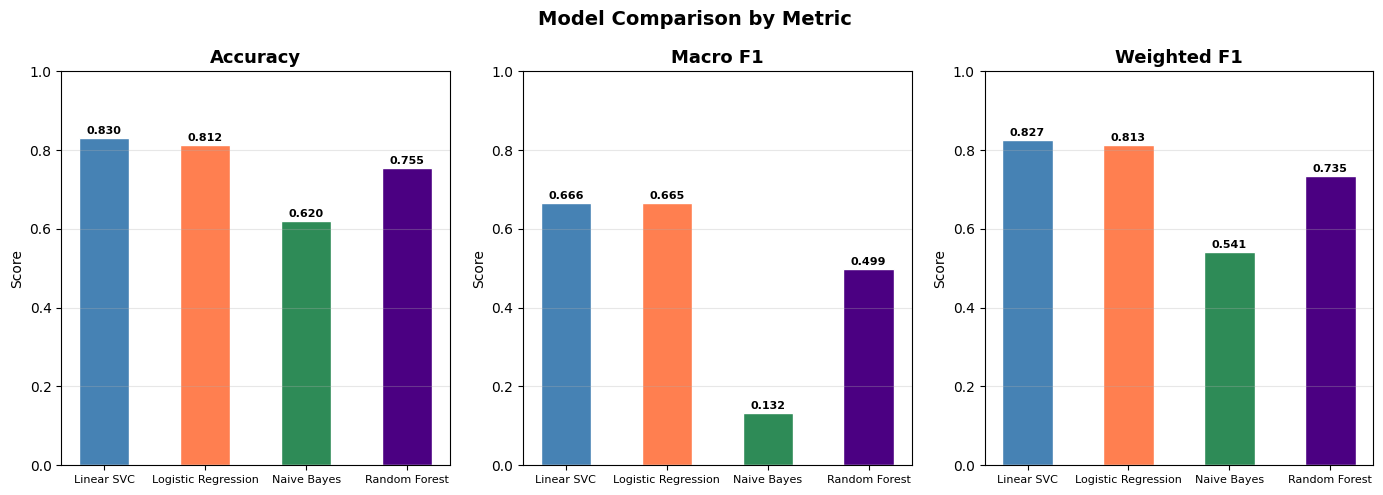

In [424]:
# Visualize model performance
models_data = [
    ("Linear SVC", y_pred_sv),
    ("Logistic Regression", y_pred_lr),
    ("Naive Bayes", y_pred_nb),
    ("Random Forest", y_pred_rf)
]

results = []
for model_name, y_pred in models_data:
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted")
    })
results_df = pd.DataFrame(results)

# Plot
metrics = ["Accuracy", "Macro F1", "Weighted F1"]
model_colors = ["steelblue", "coral", "seagreen", "indigo"]
models = results_df["Model"].tolist()
n = np.arange(len(models))
width = 0.5

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, (metric, ax) in enumerate(zip(metrics, axes)):
    values = results_df[metric].tolist()
    bars   = ax.bar(n, values, width, color = model_colors, edgecolor = "white")
    # Value labels
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha = "center",
            va = "bottom",
            fontsize = 8,
            fontweight = "bold"
        )
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylabel("Score", fontsize=10)
    ax.set_xticks(n)
    ax.set_xticklabels(models, fontsize = 8)
    ax.set_ylim(0, 1.0)
    ax.yaxis.grid(True, alpha=0.3)
fig.suptitle("Model Comparison by Metric", fontsize = 14, fontweight = "bold")

plt.tight_layout()
plt.show()

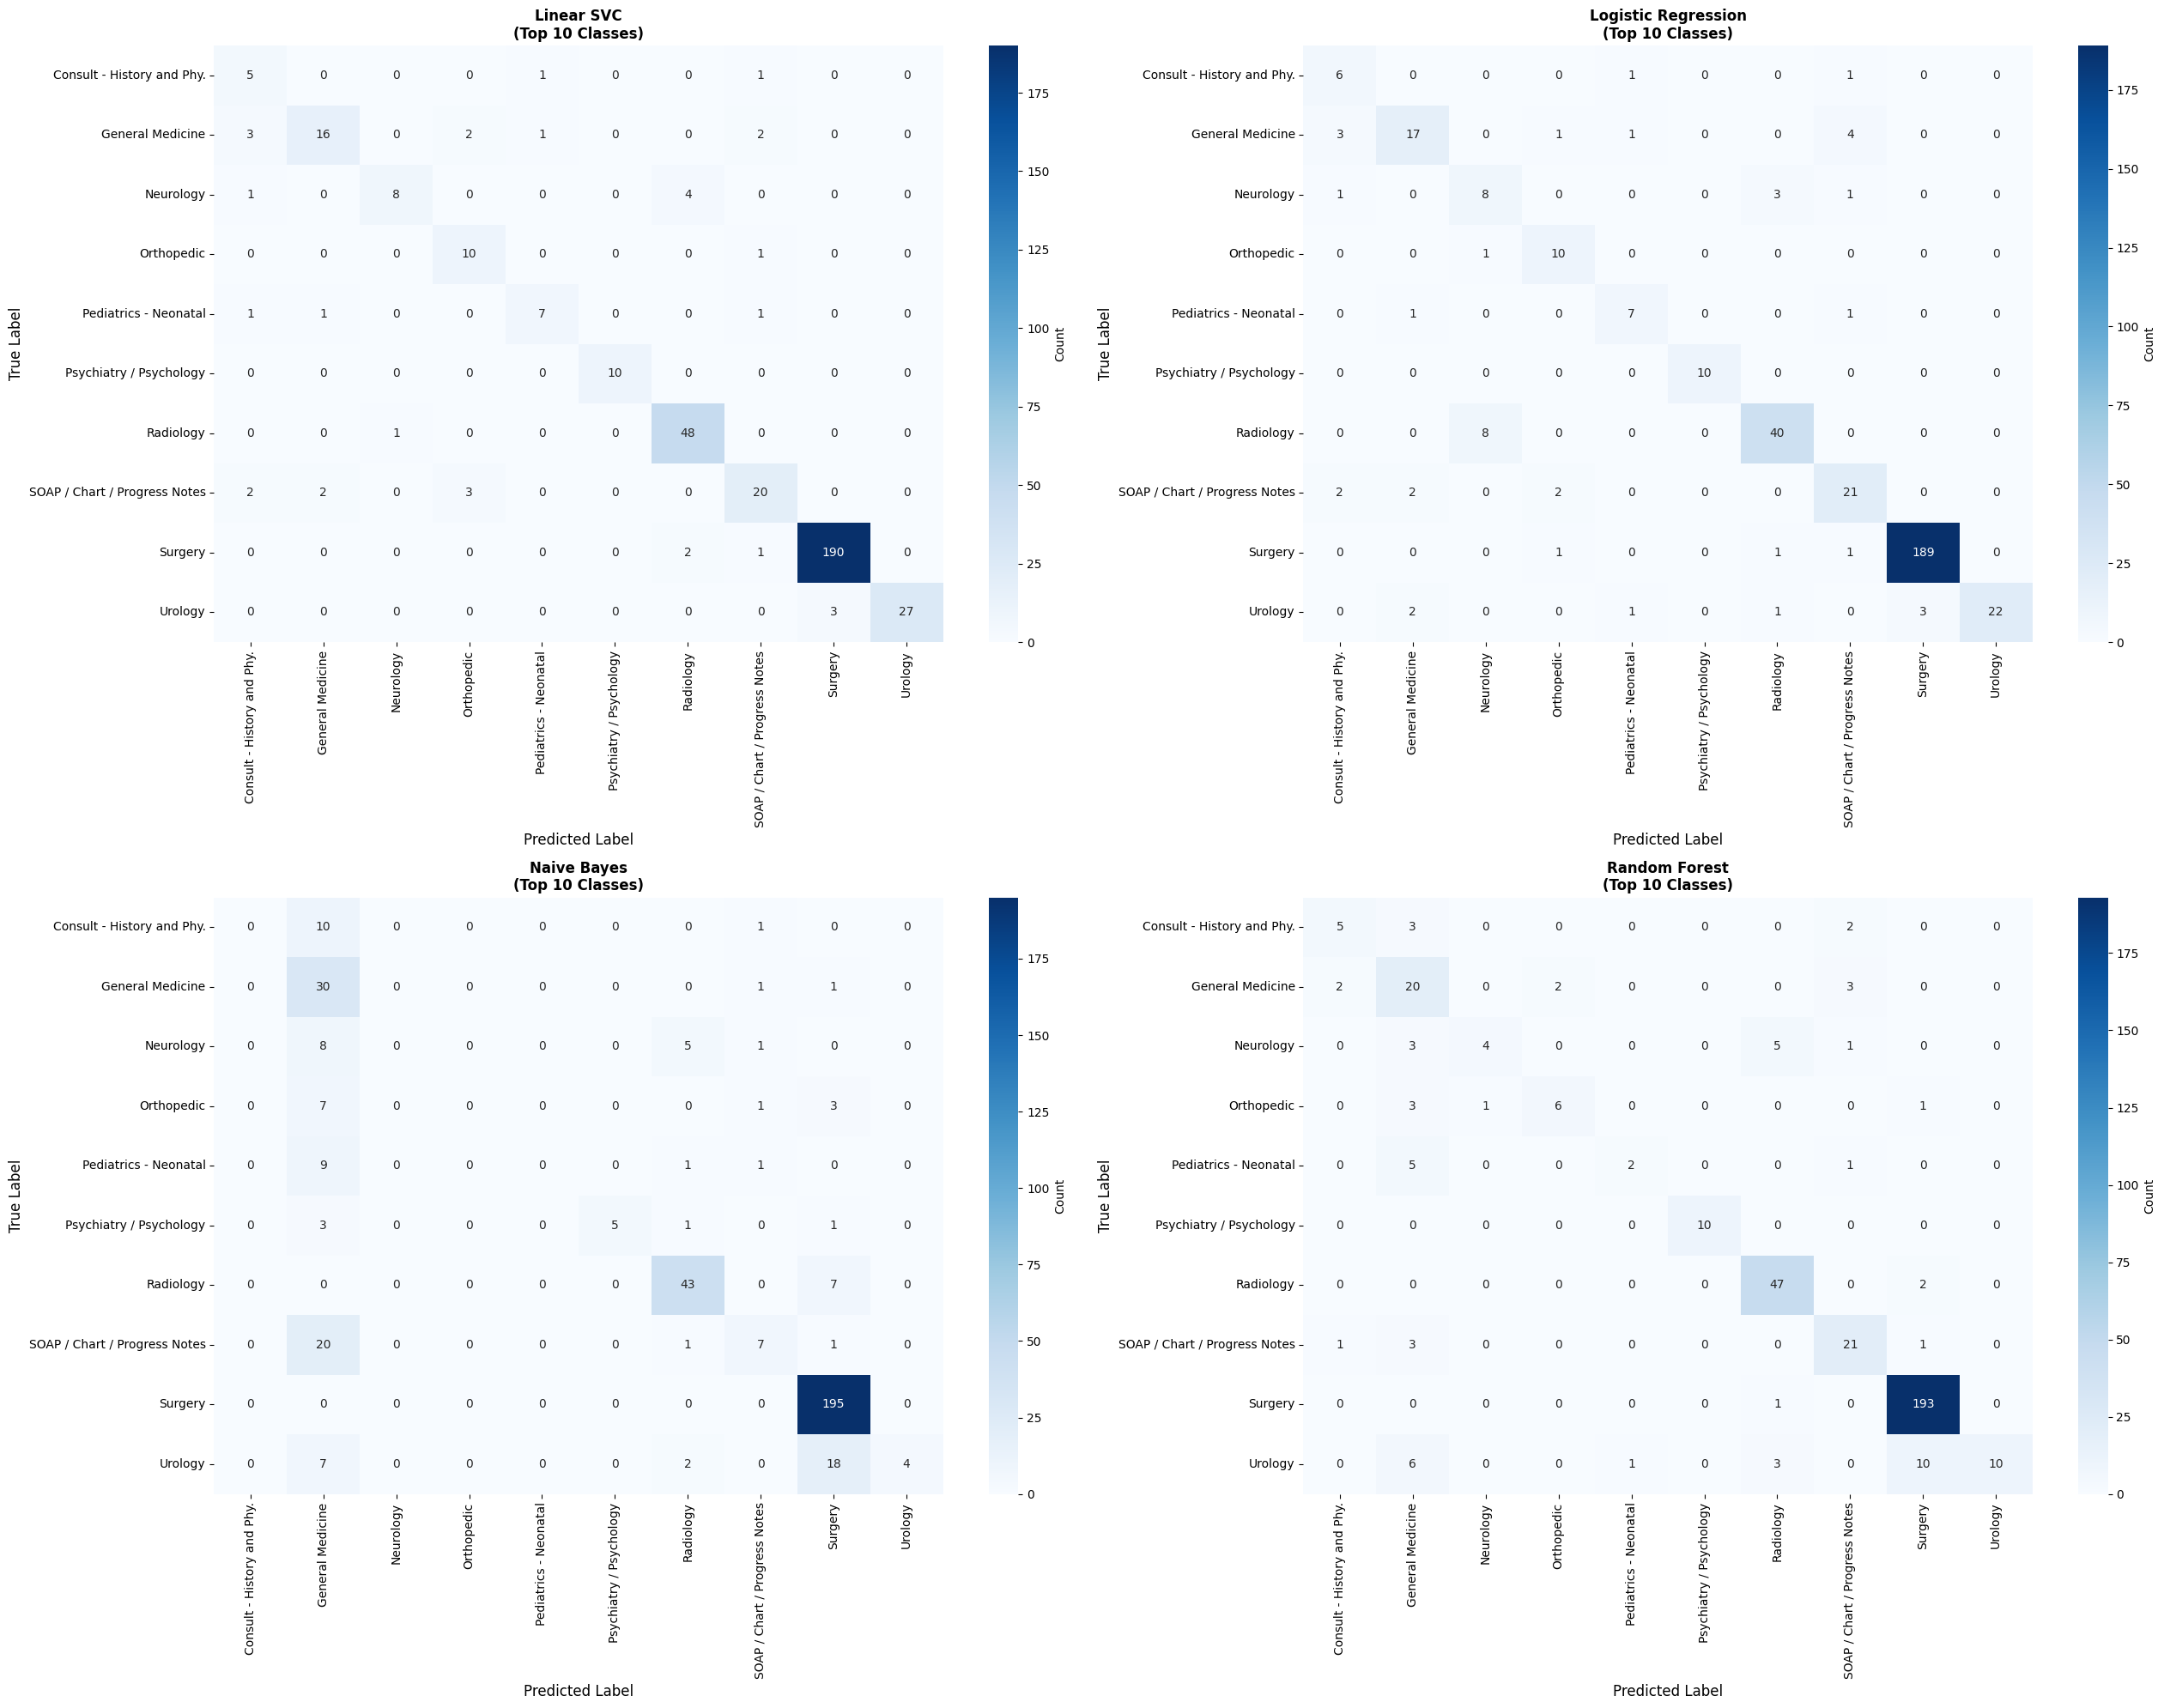


Linear SVC:
  Classes never predicted: set()
  Number of classes never predicted: 0

Logistic Regression:
  Classes never predicted: set()
  Number of classes never predicted: 0

Naive Bayes:
  Classes never predicted: {'Consult - History and Phy.', 'Podiatry', 'Ophthalmology', 'Physical Medicine - Rehab', 'Neurology', 'Obstetrics / Gynecology', 'Emergency Room Reports', 'Nephrology', 'Orthopedic', 'Cardiovascular / Pulmonary', 'Bariatrics', 'Pain Management', 'Gastroenterology', 'Discharge Summary', 'Hematology - Oncology', 'Pediatrics - Neonatal', 'ENT - Otolaryngology', 'Office Notes', 'Sleep Medicine'}
  Number of classes never predicted: 19

Random Forest:
  Classes never predicted: {'Gastroenterology', 'Bariatrics'}
  Number of classes never predicted: 2


In [425]:
# Visualize where the "leaks" are
top_classes = sorted(y_test.value_counts().head(10).index)
mask = y_test.isin(top_classes)

fig, axes = plt.subplots(2, 2, figsize=(26, 20))
axes_flat = axes.flatten()

for idx, (model_name, y_pred) in enumerate(models_data):
    cm = confusion_matrix(y_test[mask], y_pred[mask], labels=top_classes)
    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues",
                xticklabels = top_classes, yticklabels = top_classes,
                cbar_kws = {"label": "Count"}, ax = axes_flat[idx]
    )
    axes_flat[idx].set_title(f"{model_name}\n(Top 10 Classes)", fontsize = 12, fontweight = "bold")
    axes_flat[idx].set_ylabel("True Label", fontsize=12)
    axes_flat[idx].set_xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.show()

# Classes each model never predicted
for idx, (model_name, y_pred) in enumerate(models_data):
    predicted_classes = set(y_pred)
    true_classes = set(y_test)
    never_predicted = true_classes - predicted_classes
    print(f"\n{model_name}:")
    print(f"  Classes never predicted: {never_predicted}")
    print(f"  Number of classes never predicted: {len(never_predicted)}")

In [426]:
# Error Analysis - Logistic Regression
# Why did this happen?
y_pred_proba = lr_model.predict_proba(X_test_tfidf)
max_proba = y_pred_proba.max(axis=1)
error_df = pd.DataFrame({
    "index": range(len(y_test)),
    "true": y_test.values,
    "predicted": y_pred_lr,
    "confidence": max_proba,
    "correct": y_test.values == y_pred_lr
})

confident_errors = error_df[~error_df["correct"]].sort_values("confidence", ascending=False).head(5)
print("Top 5 Confident Errors - Logistic Regression")
print("-"*85)
print(f"{'Index':<8} {'True':<30} {'Predicted':<33} {'Confidence':<12}")
print("-"*85)
for idx, row in confident_errors.iterrows():
    print(f"{row['index']:<8} {row['true']:<30} {row['predicted']:<33} {row['confidence']:<12.4f}")

print('\n"Confident But Wrong" Samples')
X_test_list = X_test.tolist()
for idx, row in confident_errors.iterrows():
    sample_idx = row["index"]
    print(f"{'-'*60}")
    print(f"Sample {sample_idx}:")
    print(f"True: {row['true']}")
    print(f"Predicted: {row['predicted']} (Confidence: {row['confidence']:.2%})")
    print(f"\nText preview:")
    print(X_test_list[sample_idx][:300] + "...")
    print(f"Text length: {len(X_test_list[sample_idx])} characters")

Top 5 Confident Errors - Logistic Regression
-------------------------------------------------------------------------------------
Index    True                           Predicted                         Confidence  
-------------------------------------------------------------------------------------
150      Surgery                        Pain Management                   0.6355      
185      General Medicine               Consult - History and Phy.        0.6273      
52       Surgery                        Pain Management                   0.6133      
82       Consult - History and Phy.     SOAP / Chart / Progress Notes     0.5443      
457      Radiology                      Cardiovascular / Pulmonary        0.5268      

"Confident But Wrong" Samples
------------------------------------------------------------
Sample 150:
True: Surgery
Predicted: Pain Management (Confidence: 63.55%)

Text preview:
PROCEDURE: , Bilateral L5 dorsal ramus block and bilateral S1, S2, and S3 latera

#### Reflection:
It appears the errors are due to common misconceptions. "Consultation" will always look like Consult, and cardiac imaging reports will always look like Cardiology. Pain management procedures made by surgeons bring confusion, as well as transcriptions in SOAP format with Consult content. These errors could be due to the mislabelling/labelling choice in the data. However, the confidence isn't too high on these errors, giving validation to the model.

| Model | Accuracy | Macro F1 | Weighted F1 | Best For... |
|-------|----------|----------|-------------|----------|
| Linear SVC | 0.8297 | 0.6663 | 0.8266 | Classification |
| Logistic Regression | 0.8122 | 0.6648 | 0.8129 | Interpretability & Speed |
| Naive Bayes | 0.6201 | 0.1317 | 0.5411 | Handling Sparse Data |
| Random Forest | 0.7555 | 0.4987 | 0.7350 | Capturing Non-linear Patterns |

LOGISTIC REGRESSION MODEL:

Cardiovascular / Pulmonary
------------------------------------------------------------
Feature                        Coefficient    
---------------------------------------------
predicted                      2.8288         
heart rate                     2.3273         
capacity                       2.2316         
heart                          1.8603         
beats                          1.7265         
bronchodilator                 1.6221         
premature                      1.6217         
ventricular                    1.6013         
tilt                           1.5208         
beats minute                   1.5139         

Orthopedic
------------------------------------------------------------
Feature                        Coefficient    
---------------------------------------------
pain                           1.9670         
xyz                            1.8861         
lumbar                         1.7817         
evaluation    

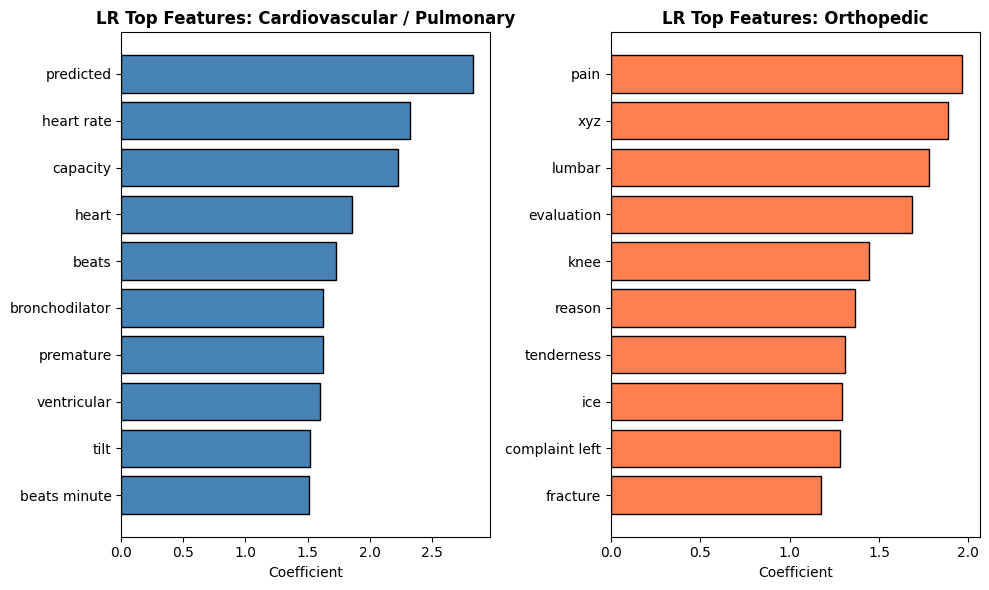

In [427]:
# Logistic Regression Coefficients (did the model learn real medicine?)
feature_names = vectorizer.get_feature_names_out()
class_names = lr_model.classes_
class_names = np.array([x.strip() for x in class_names])
coefficients = lr_model.coef_
target_specialties = ["Cardiovascular / Pulmonary", "Orthopedic"]
print("LOGISTIC REGRESSION MODEL:")
for specialty in target_specialties:
    if specialty in class_names:
        spec_idx = np.where(class_names == specialty)[0][0]
        spec_coef = coefficients[spec_idx]
        top_indices = np.argsort(spec_coef)[-10:][::-1]
        top_features = [(feature_names[i], spec_coef[i]) for i in top_indices]
        print(f"\n{specialty.strip()}")
        print(f"{'-'*60}")
        print(f"{'Feature':<30} {'Coefficient':<15}")
        print("-"*45)
        for feature, coef in top_features:
            print(f"{feature:<30} {coef:<15.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes = axes.flatten()
for idx, specialty in enumerate(target_specialties):
    if specialty in class_names:
        spec_idx = np.where(class_names == specialty)[0][0]
        spec_coef = coefficients[spec_idx]
        top_indices = np.argsort(spec_coef)[-10:][::-1]
        top_feature_names = [feature_names[i] for i in top_indices]
        top_coefs = [spec_coef[i] for i in top_indices]
        axes[idx].barh(top_feature_names, top_coefs, color=colors[idx], edgecolor="black")
        axes[idx].set_title(f"LR Top Features: {specialty}", fontsize=12, fontweight="bold")
        axes[idx].set_xlabel("Coefficient", fontsize=10)
        axes[idx].invert_yaxis()
plt.tight_layout()
plt.show()

### Phase 4 - Vector DBs and Semantic Retrieval

#### Why?
Traditional models (Phase 3) treat "Renal" and "Kidney" as two completely different entities. Embeddings represent words as mathematical coordinates in a high-dimensional space. In this space, "Renal" and "Kidney" sit right next to each other because they share a semantic context.

#### Implementation

In [428]:
from typing import List, Dict
from sentence_transformers import SentenceTransformer
import faiss

In [429]:
# Chunking Strategy
def get_chunks(text: str, specialty: str, note_id: int, keywords: List[str] = None, chunk_size: int = 300, overlap: int = 30) -> List[Dict]:
    """
    Split text into chunks and attach metadata to each chunk.
    Parameters:
    -----------
    text : str
        The text to chunk
    specialty : str
        Medical specialty label
    note_id : int
        Document ID
    keywords: List[str]
        List of keywords for each transcription (use keywords if needed ** need to change mini_rag **)
    chunk_size : int
        Number of words per chunk (default: 300)
    overlap : int
        Number of overlapping words (default: 30) (so that context isn't cut off mid-sentence)
    Returns:
    --------
    List[Dict]
        List of dictionaries, each containing chunk text and metadata
    """
    words = text.split()
    if len(words) <= chunk_size:
        return [{
            "chunk_id": 0,
            "chunk_text": text,
            "medical_specialty": specialty,
            "note_id": note_id,
            "keywords": keywords or [],
            "chunk_length": len(words)
        }]
    chunks = []
    start = 0
    chunk_id = 0
    while start < len(words):
        end = start + chunk_size
        chunk_words = words[start:end]
        chunk_text = " ".join(chunk_words)
        chunks.append({
            "chunk_id": chunk_id,
            "chunk_text": chunk_text,
            "medical_specialty": specialty,
            "note_id": note_id,
            "keywords": keywords or [],
            "chunk_length": len(chunk_words)
        })
        chunk_id += 1
        start = end - overlap

        if ((start + chunk_size) >= len(words)) and chunks: # account for spillover chunks with small size
            if start < len(words):
                remaining_words = words[start:]
                if len(remaining_words) > 50:
                    remaining = " ".join(remaining_words)
                    chunks.append({
                        "chunk_id": chunk_id,
                        "chunk_text": remaining,
                        "medical_specialty": specialty,
                        "note_id": note_id,
                        "keywords": keywords or [],
                        "chunk_length": len(remaining_words)
                    })
                else:
                    chunks[-1]["chunk_text"] += " " + " ".join(remaining_words)
                    chunks[-1]["chunk_length"] += len(remaining_words)
            break
    return chunks

# Create chunks
df_filtered = df[df["medical_specialty"].isin(valid_classes)] # counter large class imbalance / ensure classes have ample samples in both train/test sets
df_filtered = df_filtered.reset_index(drop=True)
train_df, valid_df = train_test_split( # Split documents for referencing and validation
    df_filtered,
    test_size=0.1, # use ~230 samples for validation
    random_state=42,
    stratify=df_filtered["medical_specialty"]
)
all_chunks = []
for idx, row in train_df.iterrows():
    text = row["transcription"]
    specialty = row["medical_specialty"]
    keywords = row["keywords"]
    document_chunks = get_chunks(text=text, specialty=specialty, note_id=idx, keywords=keywords, chunk_size=300, overlap=30)
    all_chunks.extend(document_chunks)
chunks_df = pd.DataFrame(all_chunks)
print(f"Original documents for Referencing: {len(train_df)}")
print(f"Total chunks: {len(chunks_df)}")
print(f"Average chunks per document: {len(chunks_df) / len(df):.2f}")

Original documents for Referencing: 2059
Total chunks: 4138
Average chunks per document: 1.76


In [430]:
# Generating Dense Vectors (Embeddings)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2") # strikes the best balance between speed and performance for this project
print(f"Embedding dimension: 384")

print(f"Processing {len(chunks_df)} chunks:")
chunk_texts = chunks_df["chunk_text"].tolist()
embeddings = embedding_model.encode(chunk_texts, show_progress_bar=True, batch_size=32)
print(f"   Shape: {embeddings.shape}")

embeddings_with_labels = list(zip(embeddings, chunks_df["medical_specialty"].tolist()))
vector, label = embeddings_with_labels[0]
print(f"\nExample:")
print(f"  Vector shape: {vector.shape}")
print(f"  Label: {label}")

Embedding dimension: 384
Processing 4138 chunks:


Batches: 100%|██████████| 130/130 [00:08<00:00, 15.02it/s]

   Shape: (4138, 384)

Example:
  Vector shape: (384,)
  Label: Surgery


In [431]:
# Building the Vector Store (FAISS)
# FAISS is best for raw speed and local execution, ChromaDB is best if you want an easier API that handles metadata storage for you
faiss.normalize_L2(embeddings) # Normalize embeddings for cosine similarity
# Create FAISS index
dimension = embeddings.shape[1] # 384
index = faiss.IndexFlatIP(dimension) # Inner Product (cosine similarity after normalization)
index.add(embeddings)
print(f"Total vectors: {index.ntotal}")
print(f"Dimension: {dimension}")

Total vectors: 4138
Dimension: 384


#### "Mini-RAG" Classifier

In [432]:
def mini_rag(query: str, k: int = 5) -> Dict:
    """
    Retrieve similar chunks and classify by majority vote.
    Parameters:
    -----------
    query : str
        Input text to classify
    k : int
        Number of similar chunks to retrieve
    Returns:
    --------
    Dict
        Classification results with details
    """
    query_embedding = embedding_model.encode([query])
    faiss.normalize_L2(query_embedding)
    distances, indices = index.search(query_embedding, k) # Similarity scores and chunk IDs
    retrieved_specialties = []
    retrieved_chunks = []
    for i, idx in enumerate(indices[0]):
        specialty = chunks_df.iloc[idx]["medical_specialty"]
        chunk_text = chunks_df.iloc[idx]["chunk_text"]
        similarity = distances[0][i]
        retrieved_specialties.append(specialty)
        retrieved_chunks.append({
            "rank": i + 1,
            "specialty": specialty,
            "similarity": similarity,
            "chunk_preview": chunk_text[:150] + "..."
        })
    specialty_counts = Counter(retrieved_specialties)
    predicted_specialty = specialty_counts.most_common(1)[0][0]
    confidence = specialty_counts[predicted_specialty] / k
    return {
        "query": query,
        "predicted_specialty": predicted_specialty,
        "confidence": confidence,
        "vote_distribution": dict(specialty_counts),
        "retrieved_specialties": retrieved_specialties,
        "retrieved_chunks": retrieved_chunks
    }

### Phase 5 - Retrieval Validation

#### Validation Set-Up

In [433]:
from typing import Tuple

In [434]:
# Validation Set-up
indexed_note_ids = set(chunks_df["note_id"])
print(f"Documents in indexing: {len(indexed_note_ids)}")
valid_df = valid_df[["medical_specialty", "transcription", "keywords"]] # use keywords if needed ** need to change mini_rag **
print(f"Documents NOT in indexing: {len(valid_df)}")

# valid_df = valid_df.sample(n=100, random_state=42) # can do this way and increase test_size, but majority of valid_df would be left unused
print(f"\nValidation Size: {len(valid_df)} documents")
print(f"Specialties: {valid_df['medical_specialty'].nunique()}")
print(f"Columns: {list(valid_df.columns)}")

train_ids = set(train_df.index)
test_ids = set(valid_df.index)
overlap = train_ids & test_ids # check overlap in indexing and validation
print(f"\nOverlap: {len(overlap)}")

Documents in indexing: 2059
Documents NOT in indexing: 229

Validation Size: 229 documents
Specialties: 25
Columns: ['medical_specialty', 'transcription', 'keywords']

Overlap: 0


#### Metric: Top-K Accuracy (Precision @ K)


Precision @ 5 Results:
   Average Precision @ 5: 0.6830
   68.3% of retrieved chunks match the query specialty

Precision @ 5 Distribution
--------------------------------------------------
Score      Count      Percentage     
-----------------------------------
0.00       21         9.2%
0.20       26         11.4%
0.40       24         10.5%
0.60       27         11.8%
0.80       28         12.2%
1.00       103        45.0%


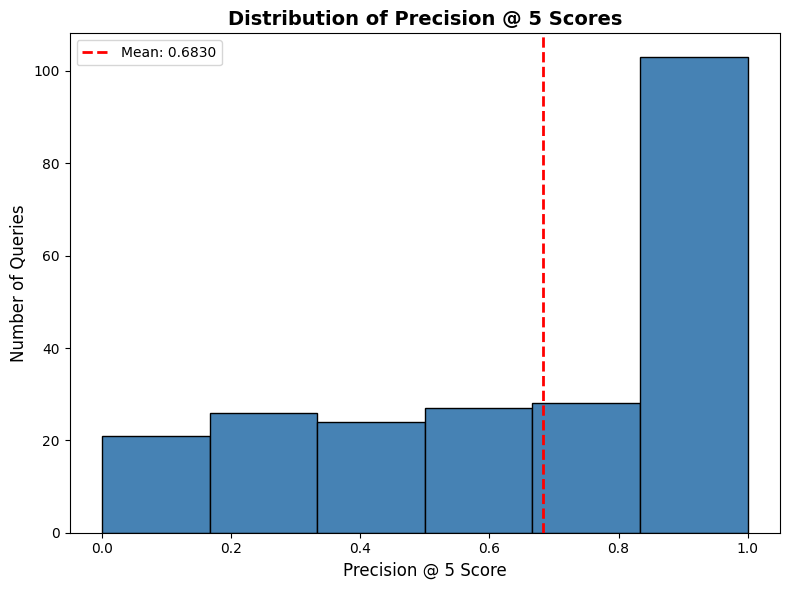

In [435]:
precision_scores = []
all_retrieved = []
all_true_labels = []
all_majority_vote = []
for idx, row in valid_df.iterrows():
    query = row["transcription"]
    true_label = row["medical_specialty"]
    result = mini_rag(query, k=5)
    matches = sum(1 for s in result["retrieved_specialties"] if s == true_label)
    precision = matches / 5
    precision_scores.append(precision)
    all_retrieved.append(result["retrieved_specialties"])
    all_true_labels.append(true_label)
    all_majority_vote.append(result["predicted_specialty"])

avg_precision_at_5 = np.mean(precision_scores)
print(f"\nPrecision @ 5 Results:")
print(f"   Average Precision @ 5: {avg_precision_at_5:.4f}")
print(f"   {avg_precision_at_5:.1%} of retrieved chunks match the query specialty")

precision_distribution = pd.Series(precision_scores).value_counts().sort_index()
print(f"\nPrecision @ 5 Distribution")
print("-"*50)
print(f"{'Score':<10} {'Count':<10} {'Percentage':<15}")
print("-" * 35)
for score, count in precision_distribution.items():
    percentage = (count / len(precision_scores)) * 100
    print(f"{score:<10.2f} {count:<10} {percentage:<3.1f}%")

plt.figure(figsize=(8, 6))
plt.hist(precision_scores, bins=6, range=(0, 1), edgecolor="black", color="steelblue")
plt.xlabel("Precision @ 5 Score", fontsize=12)
plt.ylabel("Number of Queries", fontsize=12)
plt.title("Distribution of Precision @ 5 Scores", fontsize=14, fontweight="bold")
plt.axvline(avg_precision_at_5, color="red", linestyle="--", linewidth=2, label=f"Mean: {avg_precision_at_5:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

#### Retrieval Confusion Matrix

Classes not predicted: {'Physical Medicine - Rehab', 'Ophthalmology', 'Cardiovascular / Pulmonary'}
Number of Classes: 25


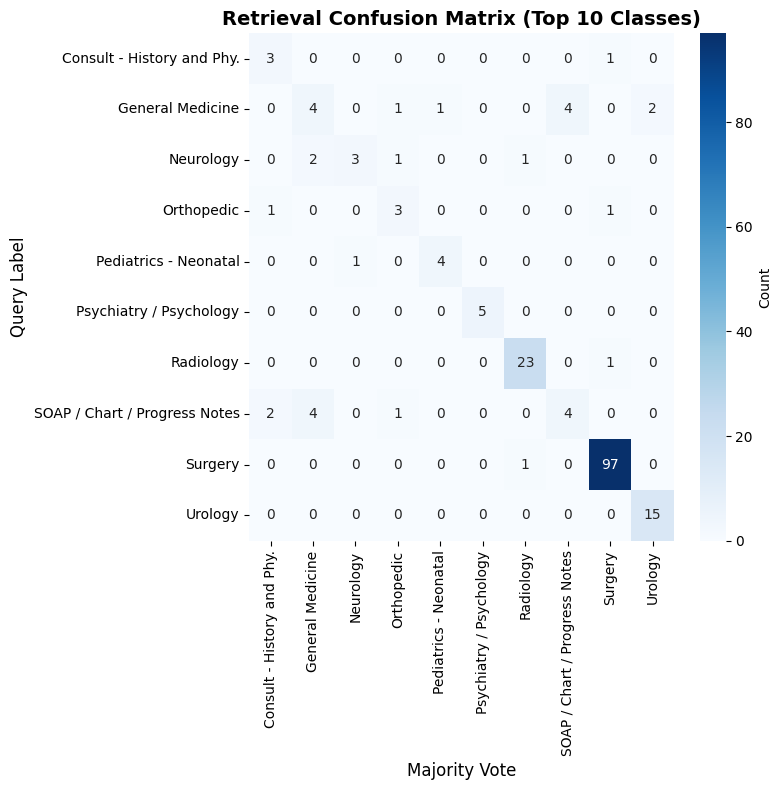

In [436]:
# Visualize where the "leaks" are
classes = sorted(set(all_true_labels + all_majority_vote))
cm = confusion_matrix(all_true_labels, all_majority_vote, labels=classes)
print(f"Classes not predicted: {set(all_true_labels) - set(all_majority_vote)}")
print(f"Number of Classes: {len(classes)}")

plt.figure(figsize=(8, 8))
top_classes = pd.Series(all_true_labels).value_counts().head(10).index
mask = [c in top_classes for c in classes]
cm_subset = cm[mask][:, mask]
classes_subset = [c for c in classes if c in top_classes]
sns.heatmap(cm_subset, annot=True, fmt="d", cmap="Blues", xticklabels=classes_subset, yticklabels=classes_subset, cbar_kws={"label": "Count"})
plt.title("Retrieval Confusion Matrix (Top 10 Classes)", fontsize=14, fontweight="bold")
plt.ylabel("Query Label", fontsize=12)
plt.xlabel("Majority Vote", fontsize=12)
plt.tight_layout()
plt.show()

In [437]:
# Semantic Overlaps
# This isn't necessarily a failure, it reflects how similar the language is in between certain fields
misclass_df = pd.DataFrame({
    "true": all_true_labels,
    "predicted": all_majority_vote
})
misclass_df = misclass_df[misclass_df["true"] != misclass_df["predicted"]]
misclass_patterns = misclass_df.groupby(["true", "predicted"]).size().reset_index(name="count")
misclass_patterns = misclass_patterns.sort_values("count", ascending=False)
print("\nTop 10 Semantic Overlaps")
print(f"{'True Specialty':<30} {'->  Retrieved Specialty':<32} {'Count':<10}")
print("-" * 70)
for idx, row in misclass_patterns.head(10).iterrows():
    print(f"{row['true']:<30} ->  {row['predicted']:<29} {row['count']:<10}")


Top 10 Semantic Overlaps
True Specialty                 ->  Retrieved Specialty          Count     
----------------------------------------------------------------------
SOAP / Chart / Progress Notes  ->  General Medicine              4         
General Medicine               ->  SOAP / Chart / Progress Notes 4         
General Medicine               ->  Obstetrics / Gynecology       2         
General Medicine               ->  Urology                       2         
Cardiovascular / Pulmonary     ->  Radiology                     2         
ENT - Otolaryngology           ->  Surgery                       2         
Emergency Room Reports         ->  Consult - History and Phy.    2         
SOAP / Chart / Progress Notes  ->  Consult - History and Phy.    2         
General Medicine               ->  Emergency Room Reports        2         
Neurology                      ->  General Medicine              2         


#### Reflection:
Similar to the machine learning models, there appears to be many semantic overlaps between medical specialties. So, the misclassifications in the semantic retrieval may be purely due to these overlaps and/or mislabelling/labelling choices, not the semantic retrieval system design itself.